________________________________________________________________________

**Projet de Groupe : Nassim EL HADDAD, Eliott Colson, Issam Hamidi, Amélie Buret**

**🧠 Objectif du projet : On doit prédire la probabilité qu’un bâtiment ait au moins un sinistre pendant la période assurée. La variable cible est binaire : 0 ou 1.**

**⚠️ SVP supprimer pas le code déjà programmé mais ajouter/modifier du code en vous basant sur les codes vus en cours**

________________________________________________________________________


# 1. Initialisation

### Prérequis — exécution locale (hors Colab)

Si vous travaillez sur votre PC, exécutez **cette cellule en premier**, puis la cellule d'imports (`pandas`, `sklearn`, etc.) : elle télécharge les scripts du cours sans `wget`.

In [444]:
import subprocess
import sys
import urllib.request
from pathlib import Path

# Dépendances des scripts du cours (visualization.py → seaborn, andrea_models.py → statsmodels)
for pkg in ("seaborn", "statsmodels"):
    try:
        __import__(pkg)
    except ImportError:
        print(f"Installation de {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

_data_dir = Path(".")
for filename, url in [
    ("andrea_models.py", "https://raw.githubusercontent.com/andreaaraldo/machine-learning-for-networks/master/course_library/andrea_models.py"),
    ("feature_engineering.py", "https://raw.githubusercontent.com/andreaaraldo/machine-learning-for-networks/master/course_library/feature_engineering.py"),
    ("visualization.py", "https://raw.githubusercontent.com/andreaaraldo/machine-learning-for-networks/master/course_library/visualization.py"),
]:
    path = _data_dir / filename
    if not path.exists():
        print(f"Téléchargement de {filename}...")
        urllib.request.urlretrieve(url, path)
    else:
        print(f"{filename} déjà présent.")

andrea_models.py déjà présent.
feature_engineering.py déjà présent.
visualization.py déjà présent.


In [445]:
import pandas as pd # For dataframes (tables)
import numpy as np # For arange
import matplotlib.pyplot as plt # For plots
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import math # for sqrt
from sklearn.model_selection import cross_val_score, KFold
import pickle # to serialize/deserialize objects
from pandas.plotting import scatter_matrix

from statistics import mean

# --- Colab uniquement (wget absent sous Windows) ---
# !wget https://raw.githubusercontent.com/andreaaraldo/machine-learning-for-networks/master/course_library/andrea_models.py
# !wget https://raw.githubusercontent.com/andreaaraldo/machine-learning-for-networks/master/course_library/feature_engineering.py
# !wget https://raw.githubusercontent.com/andreaaraldo/machine-learning-for-networks/master/course_library/visualization.py
# Sous Windows : exécuter la cellule 3 avant celle-ci (téléchargement via urllib).

from andrea_models import AndreaLinearRegression  # In the course library
import feature_engineering  # From the course library
import visualization
from visualization import plot_conf_mat

print("Imports OK (pandas, sklearn, modules du cours).")

Imports OK (pandas, sklearn, modules du cours).


In [446]:
savefigures=False

________________________________________________________________________

**Récupération du dataset**

________________________________________________________________________

In [447]:
# Colab uniquement — sous Windows, passer cette cellule (CSV déjà dans le dossier).
# !wget https://raw.githubusercontent.com/Robert-ung/machine-learning-for-networks/refs/heads/main/X_train.csv
print("Colab : décommenter le wget ci-dessus. Local : utiliser la cellule de chargement plus bas.")

Colab : décommenter le wget ci-dessus. Local : utiliser la cellule de chargement plus bas.


In [448]:
# !wget https://raw.githubusercontent.com/Robert-ung/machine-learning-for-networks/refs/heads/main/X_test.csv
print("(cellule Colab — ignorée en local)")

(cellule Colab — ignorée en local)


In [449]:
# !wget https://raw.githubusercontent.com/Robert-ung/machine-learning-for-networks/refs/heads/main/y_train.csv
print("(cellule Colab — en local utiliser y_train_saegPGl.csv)")

(cellule Colab — en local utiliser y_train_saegPGl.csv)


In [450]:
# !ls  # Colab
from pathlib import Path
print("Fichiers du projet :", sorted(p.name for p in Path(".").glob("*.csv")))

Fichiers du projet : ['X_test.csv', 'X_train.csv', 'submission_proba.csv', 'y_train_saegPGl.csv']


### Chargement local des données

Les cellules `wget` ci-dessus ciblent Google Colab. Sur votre machine, les fichiers `X_train.csv`, `X_test.csv` et `y_train_saegPGl.csv` sont déjà dans le dossier du projet : exécutez la cellule suivante pour les charger et fusionner train + cible.

In [451]:
from pathlib import Path

DATA_DIR = Path(".")  # répertoire Projet MAIA

X_train = pd.read_csv(DATA_DIR / "X_train.csv", index_col=0)
X_test = pd.read_csv(DATA_DIR / "X_test.csv", index_col=0)
y_train = pd.read_csv(DATA_DIR / "y_train_saegPGl.csv", index_col=0)

# Table unique pour l'exploration (section 2+)
df = X_train.merge(y_train, on="Identifiant")

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("df (fusionné) :", df.shape)
print("Taux de sinistres (target=1) :", f"{y_train['target'].mean():.2%}")

df.head()

X_train : (10229, 25)
X_test  : (3412, 25)
y_train : (10229, 2)
df (fusionné) : (10229, 26)
Taux de sinistres (target=1) : 22.70%


,Identifiant,ft_2_categ,EXPO,ft_4_categ,ft_5_categ,ft_6_categ,ft_7_categ,ft_8_categ,ft_9_categ,ft_10_categ,...,ft_17_categ,ft_18_categ,ft_19_categ,superficief,ft_21_categ,ft_22_categ,ft_23_categ,ft_24_categ,Insee,target
0,18702,2014,1,0,V,N,1,O,1,O,...,V,base,2,1351.0,4,2012.0,0.0,2,65440,0
1,3877,2014,1,0,V,V,V,V,V,V,...,N,base,2,1972.0,2,1980.0,0.0,.,14341,1
2,4942,2013,1,1,V,V,V,V,V,V,...,N,base,2,1630.0,4,NaN,0.0,.,75109,0
3,13428,2013,"0,246575342",0,N,V,V,V,V,V,...,N,base,2,532.0,3,NaN,0.0,.,92004,0
4,17137,2015,1,0,V,N,2,O,1,O,...,V,base,2,1050.0,2,1972.0,0.0,4,59340,0


In [452]:
# À exécuter après la cellule de chargement des CSV (juste au-dessus).
assert Path("andrea_models.py").exists(), "Exécutez d'abord les cellules 3 puis 4."
assert "df" in dir() and "target" in df.columns, "Exécutez d'abord la cellule de chargement local (X_train, y_train, df)."
print("Section 1 — Initialisation : prête pour la section 2 (Visualisation).")

Section 1 — Initialisation : prête pour la section 2 (Visualisation).


# 2. Visualisation des données
---

In [453]:
# df est déjà chargé en section 1 (X_train + y_train fusionnés).
# Ligne d'origine Colab (sans la cible) :
# df = pd.read_csv('./X_train.csv')

assert "target" in df.columns, "Exécuter d'abord la section 1 (cellule chargement local)."
print("Table de travail :", df.shape)

Table de travail : (10229, 26)


In [454]:
df.head()

,Identifiant,ft_2_categ,EXPO,ft_4_categ,ft_5_categ,ft_6_categ,ft_7_categ,ft_8_categ,ft_9_categ,ft_10_categ,...,ft_17_categ,ft_18_categ,ft_19_categ,superficief,ft_21_categ,ft_22_categ,ft_23_categ,ft_24_categ,Insee,target
0,18702,2014,1,0,V,N,1,O,1,O,...,V,base,2,1351.0,4,2012.0,0.0,2,65440,0
1,3877,2014,1,0,V,V,V,V,V,V,...,N,base,2,1972.0,2,1980.0,0.0,.,14341,1
2,4942,2013,1,1,V,V,V,V,V,V,...,N,base,2,1630.0,4,NaN,0.0,.,75109,0
3,13428,2013,"0,246575342",0,N,V,V,V,V,V,...,N,base,2,532.0,3,NaN,0.0,.,92004,0
4,17137,2015,1,0,V,N,2,O,1,O,...,V,base,2,1050.0,2,1972.0,0.0,4,59340,0


In [455]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10229 entries, 0 to 10228
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Identifiant  10229 non-null  int64  
 1   ft_2_categ   10229 non-null  int64  
 2   EXPO         10229 non-null  object 
 3   ft_4_categ   10229 non-null  int64  
 4   ft_5_categ   10229 non-null  object 
 5   ft_6_categ   10229 non-null  object 
 6   ft_7_categ   10229 non-null  object 
 7   ft_8_categ   10229 non-null  object 
 8   ft_9_categ   10229 non-null  object 
 9   ft_10_categ  10229 non-null  object 
 10  ft_11_categ  10229 non-null  object 
 11  ft_12_categ  10229 non-null  object 
 12  ft_13_categ  10229 non-null  object 
 13  ft_14_categ  10229 non-null  object 
 14  ft_15_categ  10229 non-null  object 
 15  ft_16_categ  10229 non-null  object 
 16  ft_17_categ  10229 non-null  object 
 17  ft_18_categ  10229 non-null  object 
 18  ft_19_categ  10229 non-null  int64  
 19  supe

In [456]:
print("Dimensions avant nettoyage :", df.shape)
df_raw = df.copy()  # conservé pour les graphiques de la section 2

Dimensions avant nettoyage : (10229, 26)


In [457]:
'''Nettoyage des données : Remove rows with missing values'''
rows_before = len(df)
df = df.dropna()
rows_after = len(df)
print(f"Lignes supprimées (au moins une valeur manquante) : {rows_before - rows_after} ({100*(rows_before-rows_after)/rows_before:.1f} %)")
print(f"Répartition target après nettoyage :\n{df['target'].value_counts(normalize=True).rename('proportion')}")

Lignes supprimées (au moins une valeur manquante) : 1351 (13.2 %)
Répartition target après nettoyage :
target
0    0.770444
1    0.229556
Name: proportion, dtype: float64


In [458]:
df.shape

(8878, 26)

### Synthèse des valeurs manquantes

Avant le `dropna()`, on compte les manquants par colonne et on repère les variables les plus touchées (`ft_22_categ`, `superficief`, `Insee`).

In [459]:
missing = df_raw.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print("Colonnes avec valeurs manquantes (avant dropna) :\n")
print(missing)
print(f"\nLignes concernées (au moins un NA) : {df_raw.isna().any(axis=1).sum()} / {len(df_raw)}")

Colonnes avec valeurs manquantes (avant dropna) :

ft_22_categ    1236
superficief     119
Insee           115
dtype: int64

Lignes concernées (au moins un NA) : 1351 / 10229


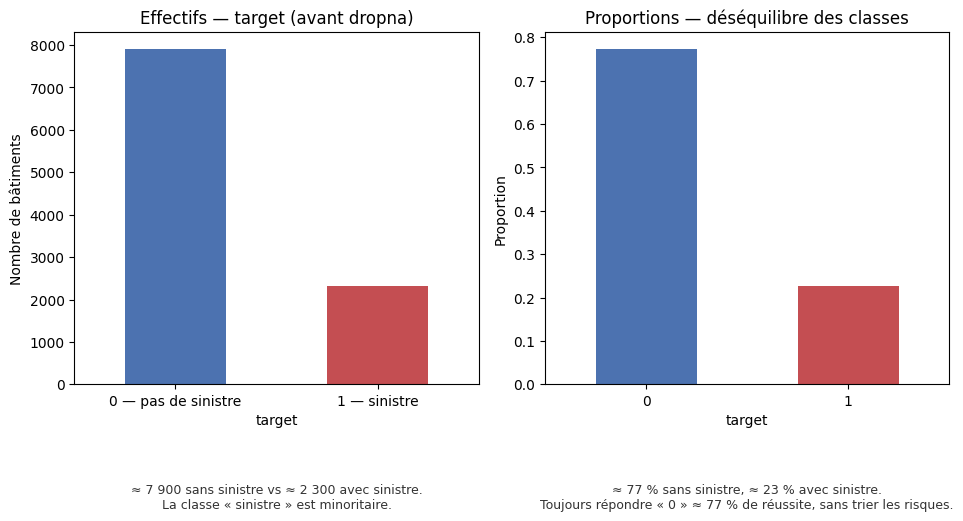

In [460]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

df_raw["target"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color=["#4c72b0", "#c44e52"])
axes[0].set_title("Effectifs — target (avant dropna)")
axes[0].set_xlabel("target")
axes[0].set_ylabel("Nombre de bâtiments")
axes[0].set_xticklabels(["0 — pas de sinistre", "1 — sinistre"], rotation=0)
axes[0].text(
    0.5,
    -0.28,
    "≈ 7 900 sans sinistre vs ≈ 2 300 avec sinistre.\nLa classe « sinistre » est minoritaire.",
    transform=axes[0].transAxes,
    ha="center",
    va="top",
    fontsize=9,
    color="#333333",
)

df_raw["target"].value_counts(normalize=True).sort_index().plot(kind="bar", ax=axes[1], color=["#4c72b0", "#c44e52"])
axes[1].set_title("Proportions — déséquilibre des classes")
axes[1].set_xlabel("target")
axes[1].set_ylabel("Proportion")
axes[1].set_xticklabels(["0", "1"], rotation=0)
axes[1].text(
    0.5,
    -0.28,
    "≈ 77 % sans sinistre, ≈ 23 % avec sinistre.\nToujours répondre « 0 » ≈ 77 % de réussite, sans trier les risques.",
    transform=axes[1].transAxes,
    ha="center",
    va="top",
    fontsize=9,
    color="#333333",
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
plt.show()

**Interprétation — déséquilibre de `target`**

- **`target` = 0** : pas de sinistre bâtiment sur la période ; **`target` = 1** : au moins un sinistre.
- Environ **77 %** de 0 et **23 %** de 1 → classe minoritaire = sinistres.
- **Pourquoi c'est important :** un modèle qui prédit toujours « 0 » peut avoir ~77 % d'accuracy sans être utile ; d'où **SMOTE** et métrique **Gini** plus tard.



In [461]:
# Variables numériques principales (jeu nettoyé)
df[["superficief", "ft_2_categ", "ft_21_categ", "ft_22_categ", "target"]].describe()

,superficief,ft_2_categ,ft_21_categ,ft_22_categ,target
count,8878.000000,8878.000000,8878.000000,8878.000000,8878.000000
mean,1899.012165,2013.677180,2.178531,1965.120185,0.229556
std,2349.614804,1.387061,0.939059,33.229134,0.420571
min,1.000000,2012.000000,1.000000,1545.000000,0.000000
25%,530.000000,2012.000000,2.000000,1960.000000,0.000000
50%,1074.500000,2013.000000,2.000000,1970.000000,0.000000
75%,2289.000000,2015.000000,3.000000,1980.000000,0.000000
max,30745.000000,2016.000000,4.000000,2016.000000,1.000000


In [462]:
# EXPO est stocké en texte avec des virgules décimales (ex. "0,246575342")
print("Type EXPO :", df["EXPO"].dtype)
print(df["EXPO"].astype(str).value_counts().head(8))

Type EXPO : object
EXPO
1              6766
0,99726776      686
0                85
0,747945205      75
0,495890411      57
0,997260274      42
0,246575342      34
0,161643836      32
Name: count, dtype: int64


In [463]:
# Corrélation des variables numériques avec la cible (indicatif)
import feature_engineering as fe

corr_target = fe.get_features_correlated_to_target(df, "target")
print("Corrélations avec target (Pearson, valeurs absolues décroissantes) :\n")
print(corr_target.head(10))

Corrélations avec target (Pearson, valeurs absolues décroissantes) :

target         1.00
superficief    0.30
ft_21_categ    0.11
ft_19_categ    0.08
ft_4_categ     0.06
Identifiant    0.05
ft_22_categ    0.02
ft_2_categ    -0.01
Name: target, dtype: float64


In [464]:
# Aperçu d'une variable catégorielle (ex. ft_5_categ : V / N / O)
df["ft_5_categ"].value_counts()

ft_5_categ
V    6418
N    2443
O      17
Name: count, dtype: int64

# 3. Représentations graphiques

> Prérequis : sections 1 et 2 exécutées (`df` nettoyé par `dropna()`, colonne `target` présente).

---

## 3.1. Boxplot

In [465]:
'''Pour chaque colonne numérique, affichage des statistiques suivantes :
count : nombre de valeurs non nulles
mean : moyenne
std : écart-type
min : valeur minimale
25% : 1er quartile
50% : médiane (ou 2e quartile)
75% : 3e quartile
max : valeur maximale'''

df.describe()

,Identifiant,ft_2_categ,ft_4_categ,ft_19_categ,superficief,ft_21_categ,ft_22_categ,target
count,8878.000000,8878.000000,8878.000000,8878.000000,8878.000000,8878.000000,8878.000000,8878.000000
mean,10330.098558,2013.677180,0.268304,1.929601,1899.012165,2.178531,1965.120185,0.229556
std,5741.685983,1.387061,0.443101,0.255832,2349.614804,0.939059,33.229134,0.420571
min,0.000000,2012.000000,0.000000,1.000000,1.000000,1.000000,1545.000000,0.000000
25%,5295.500000,2012.000000,0.000000,2.000000,530.000000,2.000000,1960.000000,0.000000
50%,10706.000000,2013.000000,0.000000,2.000000,1074.500000,2.000000,1970.000000,0.000000
75%,15412.750000,2015.000000,1.000000,2.000000,2289.000000,3.000000,1980.000000,0.000000
max,19995.000000,2016.000000,1.000000,2.000000,30745.000000,4.000000,2016.000000,1.000000


Observons d'abord la répartition de la caractéristique `superficief`.

<Axes: >

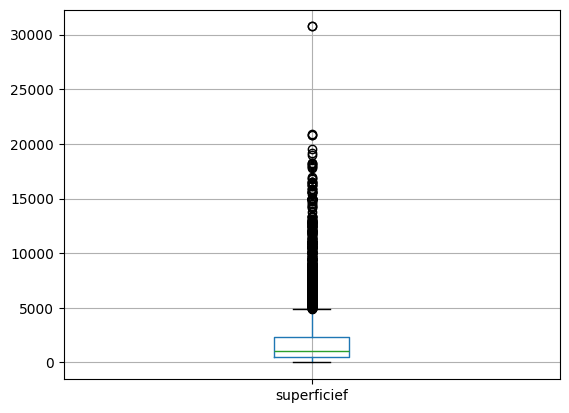

In [466]:
df.boxplot(column=['superficief'])

**Interprétation — boxplot `superficief` (superficie en m²)**

- **Boîte bleue :** 50 % centraux des bâtiments (entre Q1 et Q3).
- **Ligne verte :** **médiane** (valeur « typique ») — pas la moyenne, pas un point de données.
- **Moustaches :** étendue « habituelle » ; **cercles noirs** = **outliers** (très grandes superficies, au-dessus du 75e percentile).
- Distribution **très asymétrique** : beaucoup de petits/moyens bâtiments, quelques géants qui tirent la moyenne vers le haut.



In [467]:
# Conversion du type object de EXPO en float (virgules décimales → point)
if df['EXPO'].dtype == 'object':
    df['EXPO'] = df['EXPO'].str.replace(',', '.', regex=False).astype(float)

print("Type EXPO :", df['EXPO'].dtype)
print("Valeurs distinctes (aperçu) :", sorted(df['EXPO'].unique())[:10])
print(f"Part des contrats à EXPO = 1 : {(df['EXPO'] == 1).mean():.1%}")

Type EXPO : float64
Valeurs distinctes (aperçu) : [0.0, 0.00273224, 0.010928962, 0.016393443, 0.016438356, 0.021917808, 0.024590164, 0.024657534, 0.030054645, 0.032786885]
Part des contrats à EXPO = 1 : 76.2%


<Axes: >

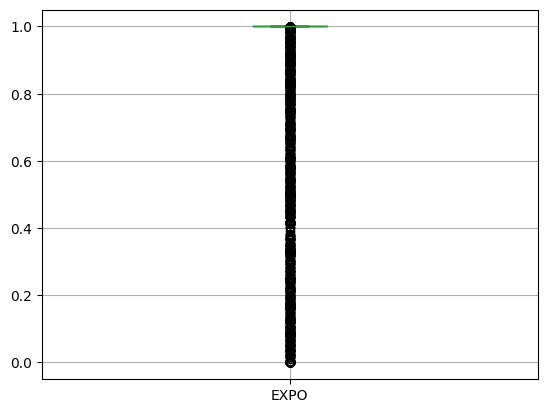

In [468]:
df.boxplot(column=['EXPO'])

**Interprétation — boxplot `EXPO`**

- **`EXPO`** = fraction de l'année où le bâtiment était **assuré** (1 = année entière, 0,5 ≈ six mois).
- Boîte **collée en haut à 1** : ~**76 %** des contrats sont des années pleines.
- Points en dessous de 1 = couvertures **partielles** (minorité).
- Boxplot peu informatif quand Q1 ≈ Q3 ≈ 1 — l'histogramme ou les effectifs sont plus parlants.



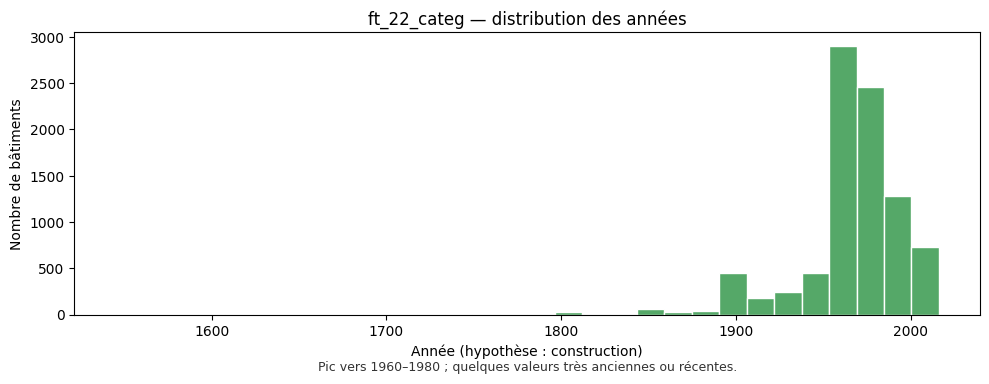

In [469]:
# ft_22_categ — histogramme (année probable de construction)
import matplotlib.pyplot as plt

years_ft22 = df["ft_22_categ"].dropna().astype(int)
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(years_ft22, bins=30, color="#55a868", edgecolor="white")
ax.set_title("ft_22_categ — distribution des années")
ax.set_xlabel("Année (hypothèse : construction)")
ax.set_ylabel("Nombre de bâtiments")
ax.text(
    0.5,
    -0.2,
    "Pic vers 1960–1980 ; quelques valeurs très anciennes ou récentes.",
    transform=ax.transAxes,
    ha="center",
    fontsize=9,
    color="#333333",
)
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.show()

`ft_22_categ` = caractéristique **anonymisée**, souvent interprétée comme **année de construction**. L’histogramme montre une forte concentration vers **1960–1980** (parc de bâtiments plutôt anciens).

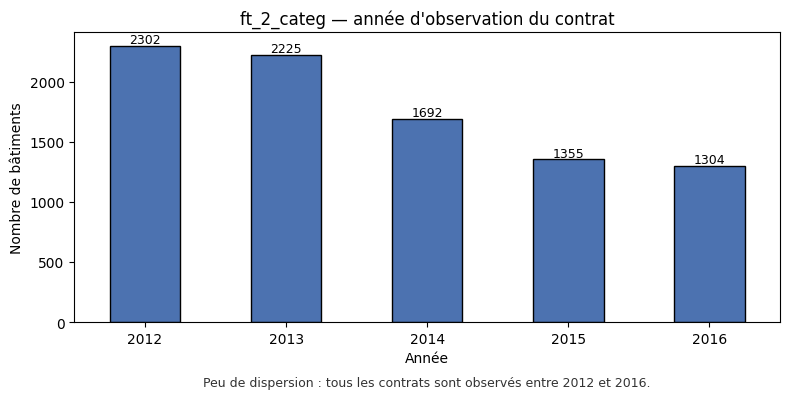

In [470]:
# ft_2_categ — année d'observation du contrat (2012–2016)
import matplotlib.pyplot as plt

counts_ft2 = df["ft_2_categ"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
counts_ft2.plot(kind="bar", ax=ax, color="#4c72b0", edgecolor="black")
ax.set_title("ft_2_categ — année d'observation du contrat")
ax.set_xlabel("Année")
ax.set_ylabel("Nombre de bâtiments")
ax.set_xticklabels([int(x) for x in counts_ft2.index], rotation=0)
for i, v in enumerate(counts_ft2.values):
    ax.text(i, v + max(counts_ft2) * 0.01, f"{int(v)}", ha="center", fontsize=9)
ax.text(
    0.5,
    -0.22,
    "Peu de dispersion : tous les contrats sont observés entre 2012 et 2016.",
    transform=ax.transAxes,
    ha="center",
    fontsize=9,
    color="#333333",
)
plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.show()

`ft_2_categ` = **année d'observation** du contrat (Challenge Data). L’histogramme ci-dessus montre combien de bâtiments par année (2012–2016) — peu de dispersion temporelle.

In [471]:
X = df['superficief'].values
X

array([1351., 1972., 1050., ..., 5580., 1754., 5400.])

In [472]:
X_sorted = np.sort(X)
X_sorted

array([1.0000e+00, 1.0000e+00, 1.0000e+00, ..., 2.0940e+04, 3.0745e+04,
       3.0745e+04])

In [473]:
K = X_sorted.size
stop = K/100 * 25
print ('stop=',stop)
stop = math.ceil(stop)
print ('stop=',stop)
print('The 25% percentile is ', X_sorted[stop])

stop= 2219.5
stop= 2220
The 25% percentile is  530.0


array([[<Axes: title={'center': 'Identifiant'}>,
        <Axes: title={'center': 'ft_2_categ'}>,
        <Axes: title={'center': 'EXPO'}>],
       [<Axes: title={'center': 'ft_4_categ'}>,
        <Axes: title={'center': 'ft_19_categ'}>,
        <Axes: title={'center': 'superficief'}>],
       [<Axes: title={'center': 'ft_21_categ'}>,
        <Axes: title={'center': 'ft_22_categ'}>,
        <Axes: title={'center': 'target'}>]], dtype=object)

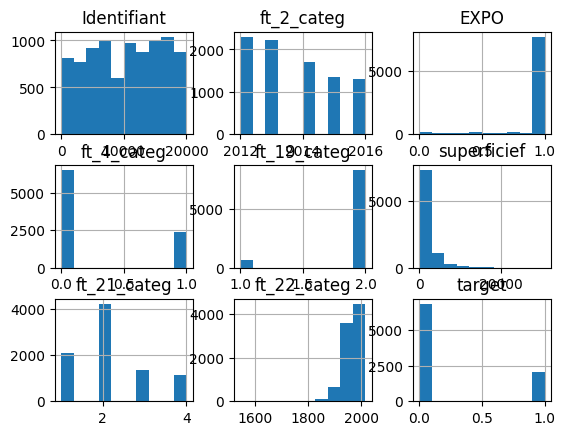

In [474]:
def plot_hist_grid(data, columns, bins=30, figsize=(18, 12), ncols=3):
    """Histogrammes en grille lisible (grande figure, espacement, titres)."""
    n = len(columns)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()
    for ax, col in zip(axes, columns):
        s = data[col].dropna()
        nuniq = int(s.nunique())
        if nuniq <= 25:
            ax.hist(s, bins=nuniq, color="#4c72b0", edgecolor="white")
        else:
            ax.hist(s, bins=bins, color="#4c72b0", edgecolor="white")
        ax.set_title(col, fontsize=12, fontweight="bold", pad=12)
        ax.tick_params(axis="both", labelsize=10)
        ax.tick_params(axis="x", rotation=25)
    for ax in axes[n:]:
        ax.set_visible(False)
    fig.suptitle("Distributions des variables numériques", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.subplots_adjust(top=0.93, hspace=0.55, wspace=0.35)
    plt.show()
    return fig

# Vue d'ensemble (sans Identifiant)
_num_cols = [c for c in df.select_dtypes(include="number").columns if c != "Identifiant"]
plot_hist_grid(df, _num_cols, bins=30, figsize=(22, 16), ncols=3)


**Interprétation — vue d'ensemble (toutes variables numériques)**

- Un panneau par colonne numérique (hors `Identifiant`) : forme de la distribution.
- Compare avec les histogrammes ciblés ci-dessous : ici vue **globale**, parfois illisible si trop de modalités.

**Légende — colonnes au nom peu clair** (Generali anonymisé ; indicatif) : `ft_2_categ` = année d'observation (2012–2016) ; `ft_21_categ` = code catégoriel (hyp. type/usage) ; `ft_22_categ` = hyp. année de construction ; `EXPO` = fraction d'année assurée (1 = année pleine) ; `superficief` = superficie (m²) ; `target` = sinistre (0/1).


array([[<Axes: title={'center': 'ft_2_categ'}>,
        <Axes: title={'center': 'ft_22_categ'}>],
       [<Axes: title={'center': 'superficief'}>,
        <Axes: title={'center': 'EXPO'}>]], dtype=object)

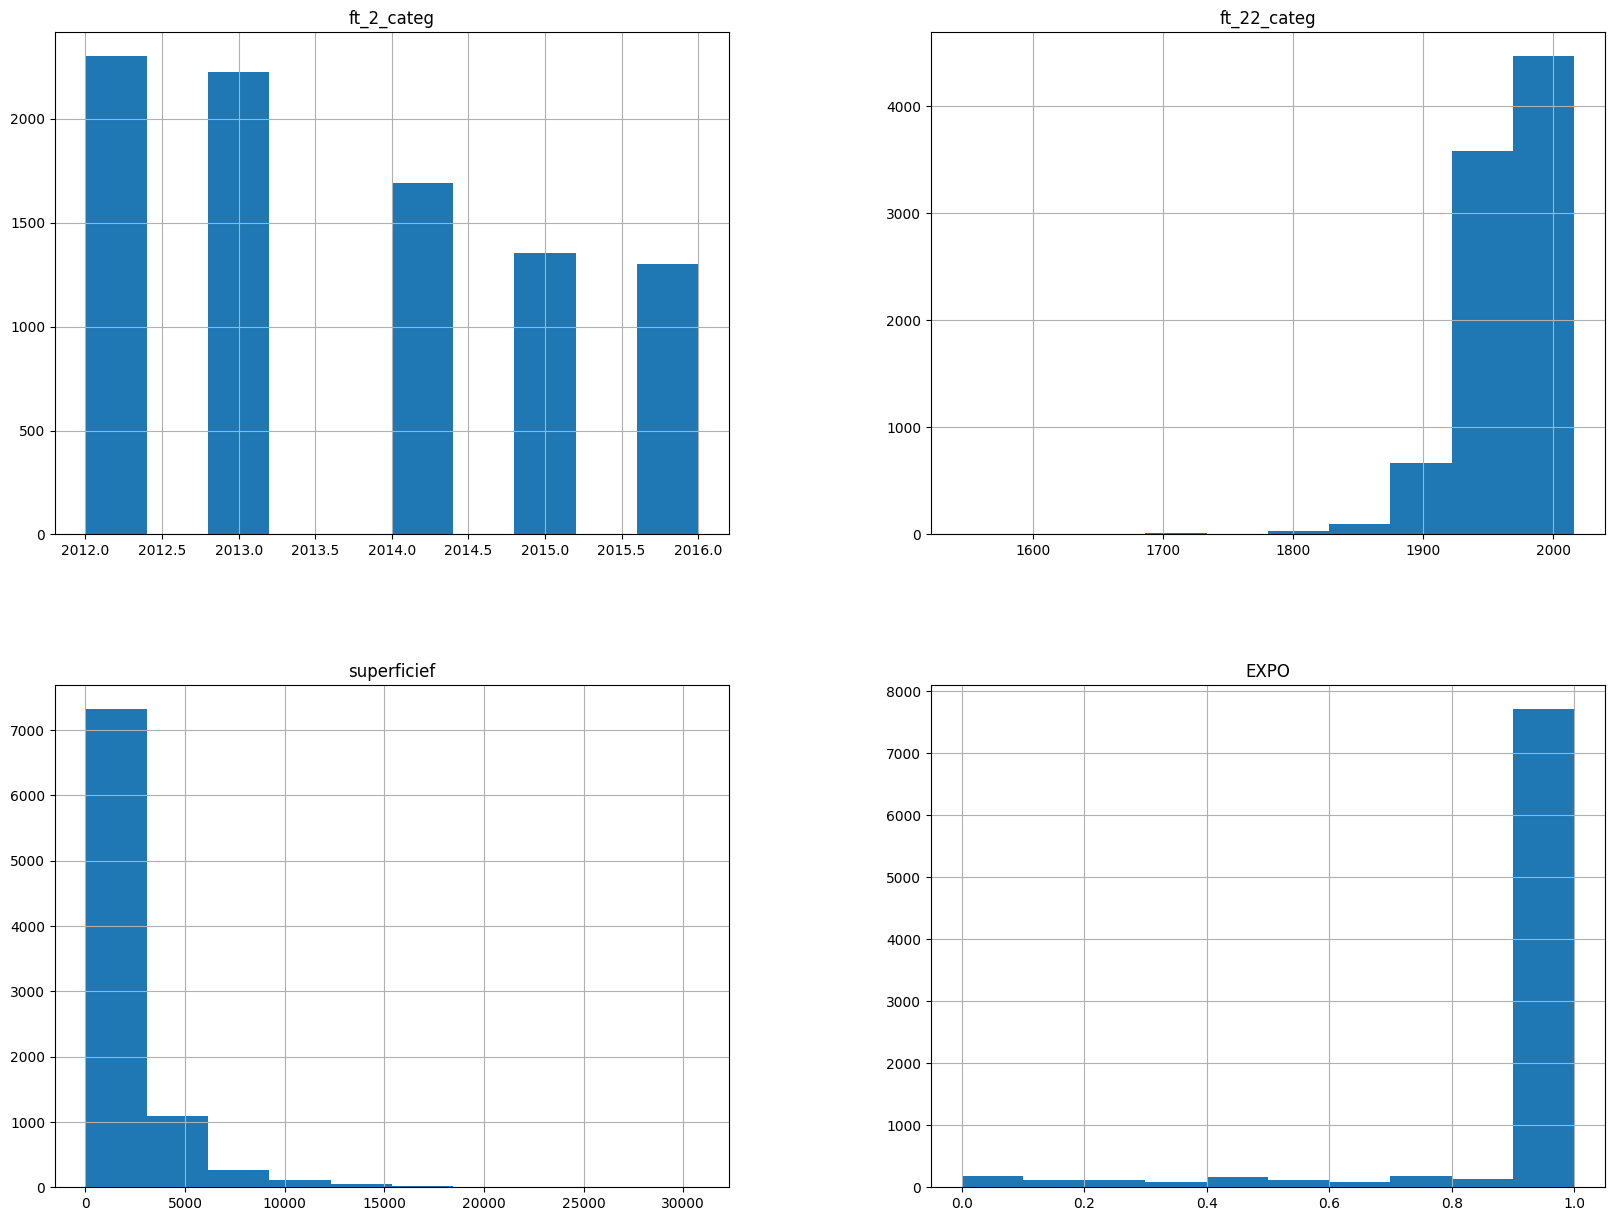

In [475]:
_key_vars = ["ft_2_categ", "ft_22_categ", "superficief", "EXPO"]
plot_hist_grid(df, _key_vars, bins=30, figsize=(16, 11), ncols=2)


**Interprétation — histogrammes des 4 variables clés**

| Variable | Lecture rapide |
|----------|----------------|
| `superficief` | Pic à gauche (petits/moyens bâtiments), longue traîne à droite |
| `EXPO` | Majorité à **1** (année pleine) |
| `ft_2_categ` | Répartition 2012–2016 |
| `ft_22_categ` | Masse vers années 1960–1980 (hyp. construction) |

**Légende — colonnes au nom peu clair** (Generali anonymisé ; indicatif) : `ft_2_categ` = année d'observation (2012–2016) ; `ft_21_categ` = code catégoriel (hyp. type/usage) ; `ft_22_categ` = hyp. année de construction ; `EXPO` = fraction d'année assurée (1 = année pleine) ; `superficief` = superficie (m²) ; `target` = sinistre (0/1).


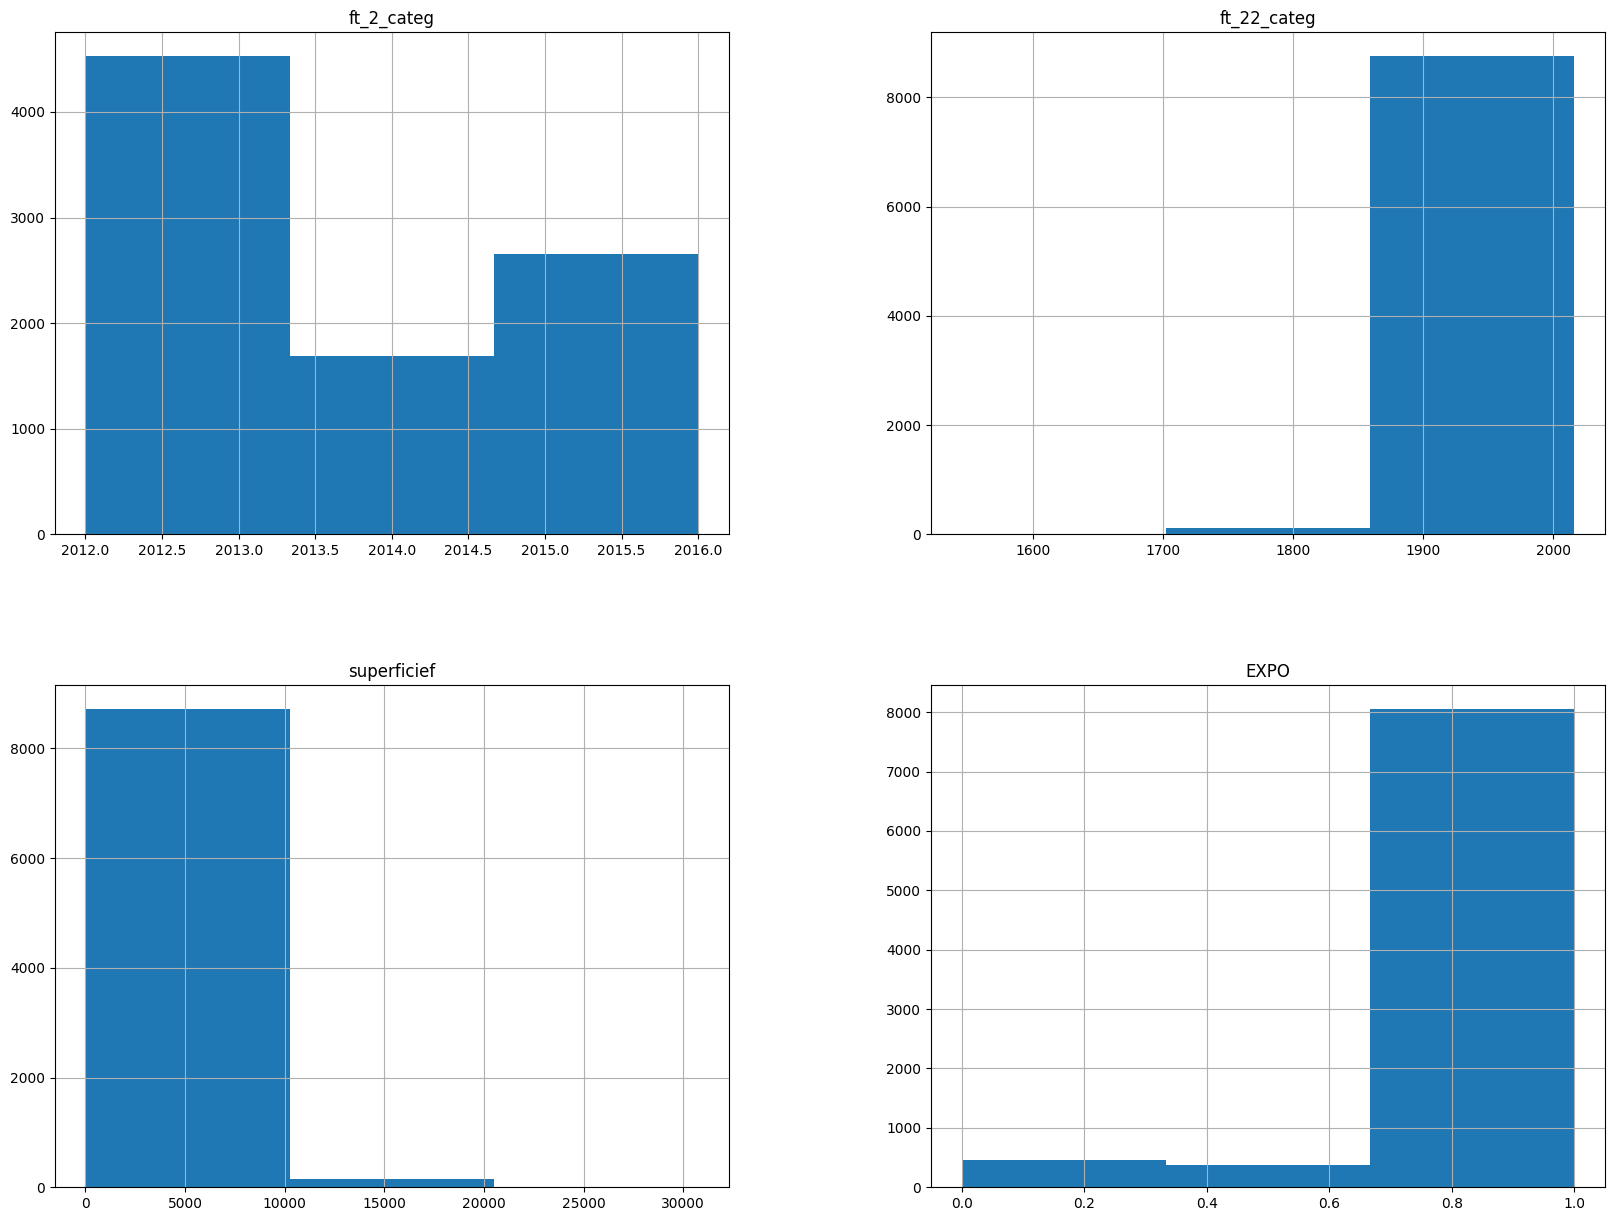

In [476]:
'''chaque histogramme aura 3 intervalles (ou "buckets") pour regrouper les valeurs. Cela simplifie la vue en faisant peu de classes.'''
plot_hist_grid(df, _key_vars, bins=3, figsize=(16, 11), ncols=2)


**Interprétation — histogrammes (3 classes seulement)**

- Même 4 variables qu'au-dessus, mais **3 intervalles** par variable → vue **très grossière**.
- Utile pour voir grossièrement où se concentre la masse (ex. petits bâtiments, EXPO = 1).

**Légende — colonnes au nom peu clair** (Generali anonymisé ; indicatif) : `ft_2_categ` = année d'observation (2012–2016) ; `ft_21_categ` = code catégoriel (hyp. type/usage) ; `ft_22_categ` = hyp. année de construction ; `EXPO` = fraction d'année assurée (1 = année pleine) ; `superficief` = superficie (m²) ; `target` = sinistre (0/1).


### 3.2 — Corrélations entre variables numériques

Heatmap (triangle supérieur) pour repérer les redondances et le lien avec `target`.

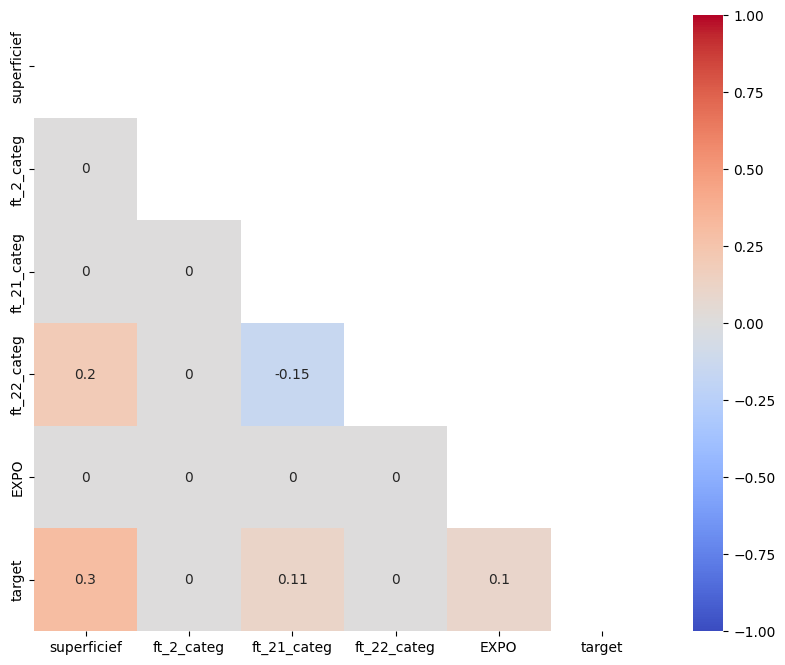

In [477]:
# EXPO doit être numérique (cellule de conversion juste au-dessus)
if df["EXPO"].dtype == "object":
    df["EXPO"] = df["EXPO"].str.replace(",", ".", regex=False).astype(float)

import visualization  # défini en section 1 ; réimport si la cellule d'imports n'a pas été relancée

_cols_corr = ["superficief", "ft_2_categ", "ft_21_categ", "ft_22_categ", "EXPO", "target"]
visualization.plot_corr(df[_cols_corr], width=10, height=8, print_value=True, thresh=0.05)
plt.show()

**Légende des variables** (colonnes `ft_*` sans libellé officiel — données Generali anonymisées ; interprétations **indicatives**) :

| Colonne | Interprétation retenue dans le projet |
|---------|----------------------------------------|
| `ft_2_categ` | Année d'**observation** du contrat (2012–2016, document Challenge Data). |
| `ft_21_categ` | Code catégoriel (1–4) — **hypothèse** : type ou usage du bâtiment (non confirmé officiellement). |
| `ft_22_categ` | Valeurs de type « année » — **hypothèse** la plus courante : année de **construction** du bâtiment. |

**Colonnes nommées explicitement :** `superficief` = superficie du bâtiment (m²) ; `EXPO` = fraction de l'année assurée (1 = année pleine) ; `target` = au moins un sinistre bâtiment sur la période (0 = non, 1 = oui).

**Interprétation — heatmap des corrélations (§ 3.2)**

- Triangle = corrélations **linéaires** (Pearson) ; seuil **0,05** : les très petites valeurs s'affichent comme 0.
- **`superficief` ↔ `target` (~0,30)** : variable la plus liée au sinistre sur ce graphique.
- **`ft_21` ↔ `target` (~0,11)** : piste secondaire ; **`ft_2`**, **`ft_22`** souvent masqués si &lt; 0,05.
- Peu de corrélations fortes **entre** features → peu de redondance à supprimer ici.


### 3.3 — Superficie selon la survenue d'un sinistre

Comparer la distribution de `superficief` entre `target = 0` et `target = 1`.

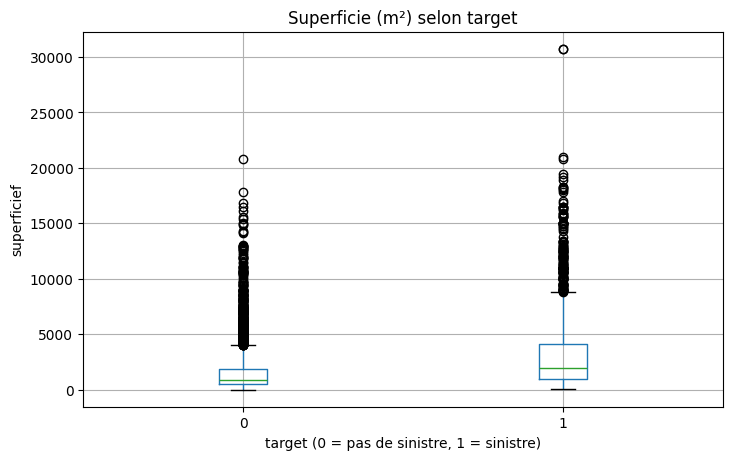

In [478]:
df.boxplot(column=["superficief"], by="target", figsize=(8, 5))
plt.suptitle("")
plt.title("Superficie (m²) selon target")
plt.xlabel("target (0 = pas de sinistre, 1 = sinistre)")
plt.ylabel("superficief")
plt.show()

**Interprétation — superficie selon sinistre ou non**

- **Deux boxplots :** `target = 0` (pas de sinistre) vs `target = 1` (sinistre).
- **Ligne verte au centre de la boîte = médiane** (50 % des bâtiments en dessous, 50 % au-dessus) — ce ne sont **pas** des points individuels.
- **Boîte bleue :** milieu de 50 % des bâtiments (Q1–Q3) ; **points noirs** = outliers (très grandes superficies).
- Médiane **plus haute** pour `target = 1` → sinistres un peu plus liés aux **grands** bâtiments ; **fort chevauchement** → la taille seule ne suffit pas.

**Colonnes :** `superficief` = superficie (m²) ; `target` = sinistre (0/1).


In [479]:
# visualization.py déjà téléchargé / importé en section 1
import visualization

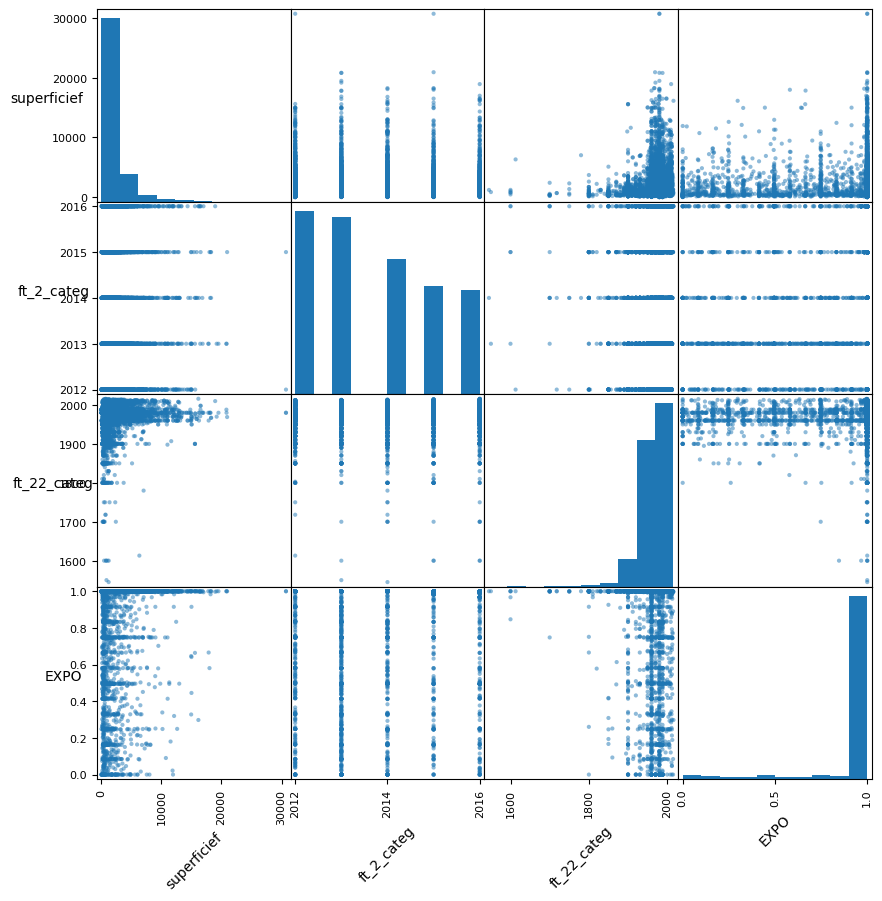

In [480]:
# We first define a function to change the rotation of the text in the plot

# The following method takes too long
#     sm = scatter_matrix(df)

# Let us just consider some features
columns_to_plot = ['superficief', 'ft_2_categ', 'ft_22_categ', 'EXPO']
sm = scatter_matrix(df[columns_to_plot],
                   figsize=(10,10))
visualization.rotate_labels(sm)
plt.show()

**Interprétation — matrice de scatter plots (4 variables)**

- **Diagonale :** histogramme de chaque variable.
- **Hors diagonale :** nuage (X = colonne, Y = ligne) — chercher une forme (montée, bandes verticales, nuage rond).
- **`EXPO` :** pic à 1 ; **`superficief` :** très asymétrique ; **`ft_2` :** 5 années ; **`ft_22` :** type « année » (construction).
- Peu de relations **linéaires fortes** entre ces 4 variables → le sinistre (`target`, absent ici) se lit mieux sur la heatmap et les modèles.

**Légende — colonnes au nom peu clair** (Generali anonymisé ; indicatif) : `ft_2_categ` = année d'observation (2012–2016) ; `ft_21_categ` = code catégoriel (hyp. type/usage) ; `ft_22_categ` = hyp. année de construction ; `EXPO` = fraction d'année assurée (1 = année pleine) ; `superficief` = superficie (m²) ; `target` = sinistre (0/1).


Nettoyage + transformation pour entraînement

In [481]:
df_cleaned = df.copy()

# 1. Remplacer les virgules par des points
for col in df_cleaned.columns:
    if df_cleaned[col].dtype == 'object':
        df_cleaned[col] = df_cleaned[col].str.replace(',', '.', regex=False)

# 2. Conversion vers float (et repérage des colonnes non numériques)
non_numeric_cols = []
for col in df_cleaned.columns:
    if col == "Identifiant":
        continue  # ID client : ne pas encoder pour le modèle
    try:
        df_cleaned[col] = df_cleaned[col].astype(float)
    except ValueError:
        non_numeric_cols.append(col)

# 3. Encodage one-hot des colonnes catégorielles restantes
df_cleaned = pd.get_dummies(df_cleaned, columns=non_numeric_cols, drop_first=False)

print("Shape df_cleaned :", df_cleaned.shape)
print("Colonnes catégorielles encodées :", len(non_numeric_cols), "→", non_numeric_cols[:5], "...")

Shape df_cleaned : (8878, 1505)
Colonnes catégorielles encodées : 16 → ['ft_5_categ', 'ft_6_categ', 'ft_7_categ', 'ft_8_categ', 'ft_9_categ'] ...


[(0.0, 25000.0),
 (2010.0, 2018.0),
 Text(0, 0.5, 'ft_2_categ'),
 Text(0.5, 0, 'superficief')]

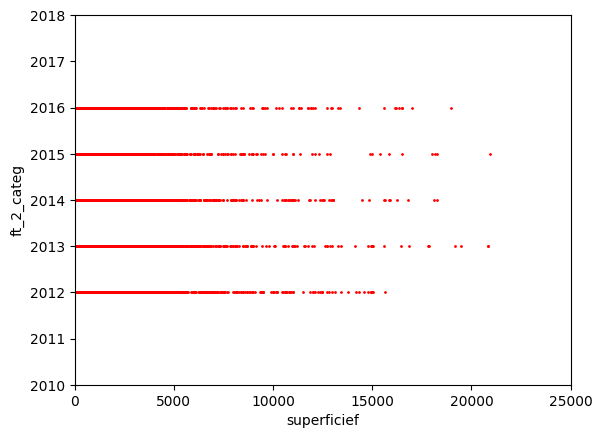

In [482]:
fig, ax = plt.subplots()
ax.scatter(df_cleaned['superficief'],
           df['ft_2_categ'],
           color='red',
           s=1,
           label='all samples')

# Customize the plot
ax.set(xlim=[0,25000],
       ylim=[2010, 2018],
       ylabel="ft_2_categ",
       xlabel="superficief")

**Interprétation — nuage de points superficie × année d'observation**

- Un point = un bâtiment ; **X** = superficie (m²), **Y** = `ft_2_categ` (années **2012–2016** seulement).
- Bandes horizontales = années discrètes ; **pas de tendance claire** « plus récent → plus grand ».
- Zone vide hors 2012–2016 = pas de données à ces dates.

**Légende — colonnes au nom peu clair** (Generali anonymisé ; indicatif) : `ft_2_categ` = année d'observation (2012–2016) ; `ft_21_categ` = code catégoriel (hyp. type/usage) ; `ft_22_categ` = hyp. année de construction ; `EXPO` = fraction d'année assurée (1 = année pleine) ; `superficief` = superficie (m²) ; `target` = sinistre (0/1).


# 4. Régression de données
---

### Prérequis — section 4 (modélisation)

Exécuter les **sections 1 à 3** avant cette partie (`df` nettoyé, `EXPO` en float si conversion faite).

**Sous Windows :** exécuter la cellule suivante, puis **sauter** les cellules Colab qui rechargent les CSV / `wget` (imports dupliqués). Les sous-sections 4.1 à 4.7 reprennent le même `df_train_cleaned`.

In [483]:
from pathlib import Path

def _prepare_train_test():
    """Charge et nettoie train / test (équivalent cellules 59-63 du cours)."""
    data = Path(".")
    X_tr = pd.read_csv(data / "X_train.csv", index_col=0)
    y_tr = pd.read_csv(data / "y_train_saegPGl.csv", index_col=0)
    X_te = pd.read_csv(data / "X_test.csv", index_col=0)
    train = X_tr.merge(y_tr, on="Identifiant")

    def _clean_numeric(d):
        out = d.copy()
        if "EXPO" in out.columns and out["EXPO"].dtype == "object":
            out["EXPO"] = out["EXPO"].str.replace(",", ".", regex=False).astype(float)
        for col in out.columns:
            if out[col].dtype == "object":
                out[col] = out[col].str.replace(",", ".", regex=False)
                try:
                    out[col] = out[col].astype(float)
                except ValueError:
                    pass
        return out.dropna()

    return _clean_numeric(train), _clean_numeric(X_te)

if "df_train_cleaned" not in dir():
    if "df" in dir() and "target" in df.columns:
        df_train_cleaned = df.copy()
        if "EXPO" in df_train_cleaned.columns and df_train_cleaned["EXPO"].dtype == "object":
            df_train_cleaned["EXPO"] = (
                df_train_cleaned["EXPO"].str.replace(",", ".", regex=False).astype(float)
            )
        print("df_train_cleaned ← df (sections 2-3), shape:", df_train_cleaned.shape)
    else:
        df_train_cleaned, _ = _prepare_train_test()
        print("df_train_cleaned chargé depuis les CSV, shape:", df_train_cleaned.shape)
else:
    print("df_train_cleaned déjà défini, shape:", df_train_cleaned.shape)

if "df_X_test_cleaned" not in dir():
    _, df_X_test_cleaned = _prepare_train_test()
    print("df_X_test_cleaned shape:", df_X_test_cleaned.shape)

LOCAL_S4_READY = True  # train + test prêts : sauter les cellules Colab de rechargement

df_train_cleaned déjà défini, shape: (8878, 27)


## 4.1. Régression linéaire à variable unique
🎯 **Objectif** : Prédire target (sinistre ou pas) à partir de superficief (la superficie du bâtiment).

---

In [484]:
# Colab : imports + wget dupliqués — sous Windows, SAUTER (déjà fait en section 1).
# from andrea_models import AndreaLinearRegression
# import feature_engineering
print("Imports du cours : utiliser la cellule 4 de la section 1.")

Imports du cours : utiliser la cellule 4 de la section 1.


In [485]:
# Colab : rechargement CSV — en local, on reconstruit df_y_train / df_X_train depuis df_train_cleaned
if "df_train_cleaned" not in dir():
    df_X_train = pd.read_csv("X_train.csv", index_col=0)
    df_X_test = pd.read_csv("X_test.csv", index_col=0)
    df_y_train = pd.read_csv("y_train_saegPGl.csv", index_col=0)
else:
    print("df_train_cleaned déjà prêt — alias df_y_train / df_X_train créés.")
    df_y_train = df_train_cleaned[["Identifiant", "target"]].copy()
    df_X_train = df_train_cleaned.drop(columns=["target"])
    if "df_X_test_cleaned" in dir():
        df_X_test = df_X_test_cleaned.copy()

df_train_cleaned déjà prêt — alias df_y_train / df_X_train créés.


In [486]:
# Aperçu de la cible (nécessite df_y_train — cellule précédente)
df_y_train[["Identifiant", "target"]]

,Identifiant,target
0,18702,0
1,3877,1
4,17137,0
5,7580,1
6,11501,0
...,...,...
10223,1605,0
10224,2710,0
10225,16868,0
10227,5319,0


In [487]:
# Fusionner X et y (Colab) — ignoré si df_train_cleaned existe déjà
if "df_train_cleaned" not in dir():
    df_train = df_X_train.merge(df_y_train, on="Identifiant")
    display(df_train.head())
else:
    df_train = df_train_cleaned.copy()
    print("df_train ← df_train_cleaned")

df_train ← df_train_cleaned


In [488]:
# Nettoyage Colab — sous Windows, souvent déjà fait (cellule locale section 4 + EXPO en float)

def _clean_numeric_frame(d):
    out = d.copy()
    if "EXPO" in out.columns and out["EXPO"].dtype == "object":
        out["EXPO"] = out["EXPO"].str.replace(",", ".", regex=False).astype(float)
    for col in out.columns:
        if out[col].dtype == "object":
            out[col] = out[col].str.replace(",", ".", regex=False)
            try:
                out[col] = out[col].astype(float)
            except ValueError:
                pass
    return out

if "LOCAL_S4_READY" in dir() and LOCAL_S4_READY:
    print("Nettoyage ignoré : df_train_cleaned / df_X_test_cleaned déjà prêts.")
    df_train = df_train_cleaned.copy()
else:
    if "df_train_cleaned" not in dir():
        df_train_cleaned = df_train.copy()
    df_train_cleaned = _clean_numeric_frame(df_train_cleaned)
    df_X_test_cleaned = _clean_numeric_frame(df_X_test)
    print("Nettoyage Colab terminé.")


Nettoyage ignoré : df_train_cleaned / df_X_test_cleaned déjà prêts.


In [489]:
# Supprimer les lignes avec des NaN (déjà fait si LOCAL_S4_READY)
if "LOCAL_S4_READY" in dir() and LOCAL_S4_READY:
    print("dropna ignoré — données déjà nettoyées en section 2-4.")
else:
    df_train_cleaned = df_train_cleaned.dropna()
    df_X_test_cleaned = df_X_test_cleaned.dropna()
    print("Shape après dropna :", df_train_cleaned.shape)

dropna ignoré — données déjà nettoyées en section 2-4.


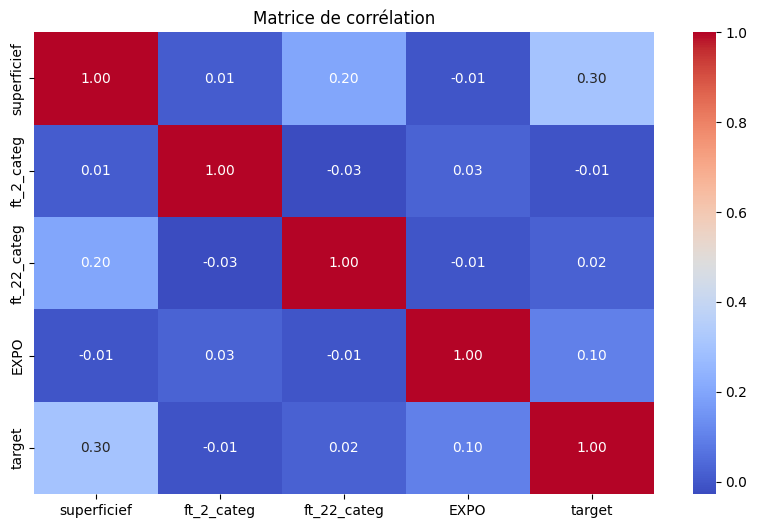

In [490]:
import seaborn as sns
import matplotlib.pyplot as plt

'''matrice de corrélation :
- Faibles corrélations générales
- La majorité des corrélations sont très proches de 0 → il y a peu de relations linéaires entre les variables.
- A quoi ça sert : Détecter les relations utiles pour des modèles de prédiction
'''

colonnes_utiles = ['superficief', 'ft_2_categ', 'ft_22_categ', 'EXPO', 'target']

plt.figure(figsize=(10, 6))
sns.heatmap(df_train_cleaned[colonnes_utiles].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()

**Interprétation — matrice de corrélation (section 4)**

- Chaque case = corrélation de **Pearson** entre −1 et +1 (rouge = positif, bleu = négatif).
- **`superficief` × `target` ≈ 0,30** : signal le plus fort ici.
- **`EXPO` × `target` ≈ 0,10** ; **`ft_2`**, **`ft_22`** : liens très faibles en linéaire.
- **`superficief` × `ft_22` ≈ 0,20** : grands bâtiments un peu plus « récents » — faible redondance.

**Légende — colonnes au nom peu clair** (Generali anonymisé ; indicatif) : `ft_2_categ` = année d'observation (2012–2016) ; `ft_21_categ` = code catégoriel (hyp. type/usage) ; `ft_22_categ` = hyp. année de construction ; `EXPO` = fraction d'année assurée (1 = année pleine) ; `superficief` = superficie (m²) ; `target` = sinistre (0/1).


In [491]:
# Let's split the dataset in 70% training set, 30% test set

df_train, df_test = train_test_split(df_train_cleaned, test_size=0.3, random_state=19)
print('Training samples ', df_train.shape[0], '; Test samples ', df_test.shape[0])

Training samples  6214 ; Test samples  2664


In [492]:
# Let's separate the independent variables from the dependent variables

X_train = df_train[['superficief'] ].values
X_train = X_train.reshape(-1,1)
y_train = df_train['target'].values
X_test = df_test[[ 'superficief'] ].values.reshape(-1,1)
y_test = df_test['target'].values

In [493]:
# Entraîner le modèle
model = AndreaLinearRegression()
model.fit(X_train, y_train, column_names=['superficief'])
model.summary()

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.093
Model:                            OLS   Adj. R-squared:                  0.093
Method:                 Least Squares   F-statistic:                     640.4
Date:                Sat, 30 May 2026   Prob (F-statistic):          1.45e-134
Time:                        16:00:36   Log-Likelihood:                -3157.9
No. Observations:                6214   AIC:                             6320.
Df Residuals:                    6212   BIC:                             6333.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
intercept       0.1285      0.007     19.611      

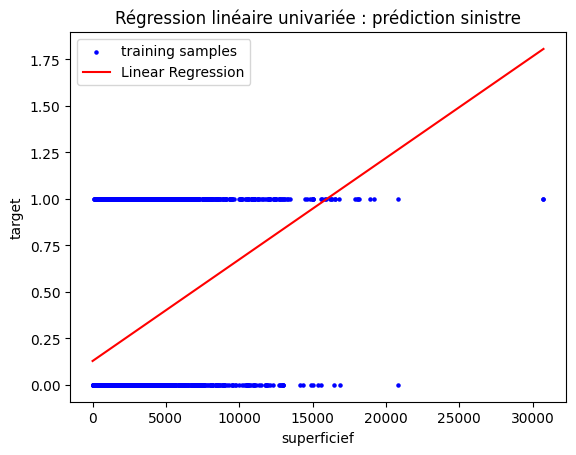

In [494]:
# Visualiser la droite de régression
interval = np.linspace(X_train.min(), X_train.max(), 300).reshape(-1, 1)
h_values = model.predict(interval)
# h_values correspond aux valeurs target prédites par le modèle de régression linéaire pour une plage de valeurs de superficief, spécifiée par la variable interval.

fig, ax = plt.subplots()
ax.scatter(X_train, y_train, color='blue', s=5, label='training samples')
ax.plot(interval, h_values, color='red', label='Linear Regression')
ax.set_xlabel("superficief")
ax.set_ylabel("target")
ax.legend()
plt.title("Régression linéaire univariée : prédiction sinistre")
plt.show()

**Interprétation — régression linéaire sur `superficief` seul** (§ 4.1)

- **Points bleus :** chaque bâtiment (superficie en X, sinistre 0/1 en Y).
- **Droite rouge :** plus la surface augmente, plus le score prédit monte (lien ~0,30 avec `target`).
- Le modèle prédit des **nombres hors [0,1]** → normal en régression linéaire sur une cible binaire ; la **logistique** (4.6) corrige cela.
- Nuage très dispersé → la superficie **aide un peu** mais **ne suffit pas**.


In [495]:
y_pred = model.predict(X_test)

In [496]:
pd.DataFrame({'true':y_test,'pred':y_pred})

,true,pred
0,0,0.136693
1,0,0.184156
2,0,0.332764
3,0,0.150332
4,0,0.131238
...,...,...
2659,0,0.390374
2660,0,0.155679
2661,1,0.565768
2662,1,0.253987


In [497]:
MSE = mean_squared_error(y_test, y_pred)
MSE

0.15939595218956257

In [498]:
RMSE_one_feature = math.sqrt(MSE)
RMSE_one_feature

0.3992442262444913

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     63.20
Date:                Sat, 30 May 2026   Prob (F-statistic):           2.20e-15
Time:                        16:00:36   Log-Likelihood:                -3431.3
No. Observations:                6214   AIC:                             6867.
Df Residuals:                    6212   BIC:                             6880.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0512      0.023      2.184      0.0

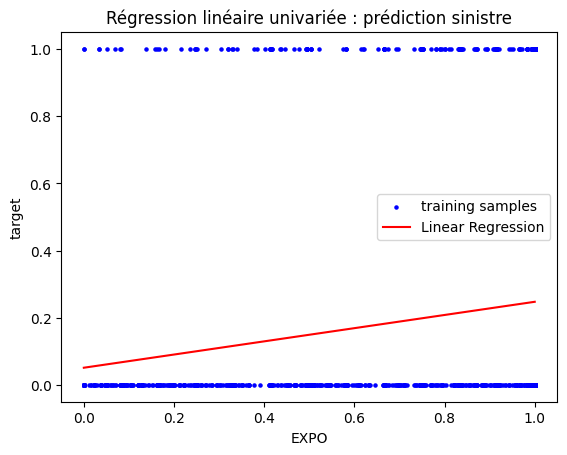

In [499]:
# EXPO - Target : Let's separate the independent variables from the dependent variables

X_train = df_train[['EXPO'] ].values
X_train = X_train.reshape(-1,1)
y_train = df_train['target'].values
X_test = df_test[[ 'EXPO'] ].values.reshape(-1,1)
y_test = df_test['target'].values

# Entraîner le modèle
model = AndreaLinearRegression()
model.fit(X_train, y_train, column_names=['EXPO'])
model.summary()

# Visualiser la droite de régression
interval = np.linspace(X_train.min(), X_train.max(), 300).reshape(-1, 1)
h_values = model.predict(interval)
# h_values correspond aux valeurs target prédites par le modèle de régression linéaire pour une plage de valeurs de superficief, spécifiée par la variable interval.

fig, ax = plt.subplots()
ax.scatter(X_train, y_train, color='blue', s=5, label='training samples')
ax.plot(interval, h_values, color='red', label='Linear Regression')
ax.set_xlabel("EXPO")
ax.set_ylabel("target")
ax.legend()
plt.title("Régression linéaire univariée : prédiction sinistre")
plt.show()

**Interprétation — régression linéaire sur `EXPO` seul** (§ 4.1)

- **Points** en bandes y = 0 et y = 1 ; **gros nuage à EXPO = 1** (années pleines).
- **Droite rouge** légèrement montante : plus de temps assuré → score un peu plus haut (corr. ~0,10 avec `target`).
- **`EXPO` = 1** : contrat sur l'année entière ; valeurs &lt; 1 = couverture partielle.
- Variable **seule insuffisante** (RMSE ~0,40) ; utile **combinée** à d'autres features.


In [500]:
y_pred = model.predict(X_test)

In [501]:
pd.DataFrame({'true':y_test,'pred':y_pred})

,true,pred
0,0,0.247428
1,0,0.247428
2,0,0.247428
3,0,0.246892
4,0,0.247428
...,...,...
2659,0,0.247428
2660,0,0.247428
2661,1,0.247428
2662,1,0.247428


In [502]:
MSE = mean_squared_error(y_test, y_pred)
MSE

0.17142018971882392

In [503]:
RMSE_one_feature = math.sqrt(MSE)
RMSE_one_feature

0.41402921360554246

## 4.2. Régression linéaire à variable unique, avec variable transformée
---

Training samples  6214 ; Test samples  2664


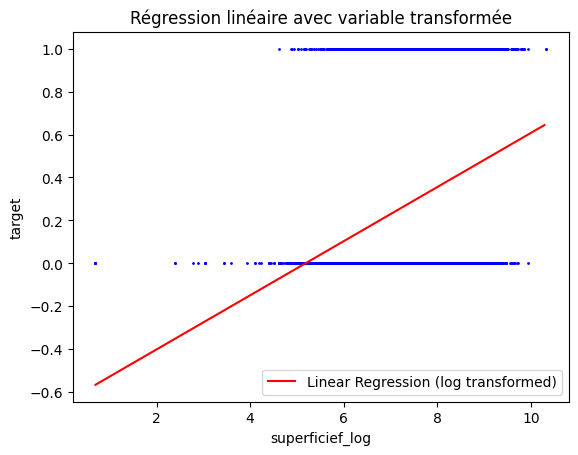

In [504]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import math
from andrea_models import AndreaLinearRegression

# On part de notre df_cleaned (train et test déjà prêts)
# On crée une nouvelle colonne transformée
df_train_cleaned['superficief_log'] = np.log(df_train_cleaned['superficief'] + 1)  # +1 pour éviter log(0)
df_X_test_cleaned['superficief_log'] = np.log(df_X_test_cleaned['superficief'] + 1)

# Let's split the dataset in 70% training set, 30% test set

df_train, df_test = train_test_split(df_train_cleaned, test_size=0.3, random_state=19)
print('Training samples ', df_train.shape[0], '; Test samples ', df_test.shape[0])

# Let's separate the independent variables from the dependent variables

X_train = df_train[['superficief_log'] ].values
X_train = X_train.reshape(-1,1)
y_train = df_train['target'].values
X_test = df_test[[ 'superficief_log'] ].values.reshape(-1,1)
y_test = df_test['target'].values

# Entraînement du modèle

model = AndreaLinearRegression()
model.fit(X_train, y_train, column_names=['superficief_log'])

# Visualisation
fig, ax = plt.subplots()
ax.scatter(df_train['superficief_log'], y_train, color='blue', s=1)
ax.set(ylabel="target", xlabel="superficief_log")

# Tracer la droite de régression
interval = np.arange(X_train.min(), X_train.max(), 0.1).reshape(-1,1)
h_values = model.predict(interval)
ax.plot(interval, h_values, label="Linear Regression (log transformed)", color = 'red')
ax.legend()
plt.title("Régression linéaire avec variable transformée")
plt.show()

**Interprétation — régression linéaire sur log(superficie)** (§ 4.2)

- **Axe X :** `superficief_log` (superficie transformée) ; **Y :** `target` (0/1).
- **Droite rouge :** tendance moyenne après compression des extrêmes — souvent **plus stable** que sur la superficie brute.
- Compare la **RMSE** au graphique 4.1 : si elle baisse peu, le log aide marginalement.


In [505]:
# 5. Évaluation du modèle
y_pred = model.predict(X_test)

# 6. Résumé statistique
model.summary()

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.094
Model:                            OLS   Adj. R-squared:                  0.094
Method:                 Least Squares   F-statistic:                     645.5
Date:                Sat, 30 May 2026   Prob (F-statistic):          1.43e-135
Time:                        16:00:37   Log-Likelihood:                -3155.6
No. Observations:                6214   AIC:                             6315.
Df Residuals:                    6212   BIC:                             6329.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
intercept          -0.6545      0.035    -

In [506]:
RMSE_1_feature = math.sqrt(mean_squared_error(y_test, y_pred) )
RMSE_1_feature

0.4008583724031047

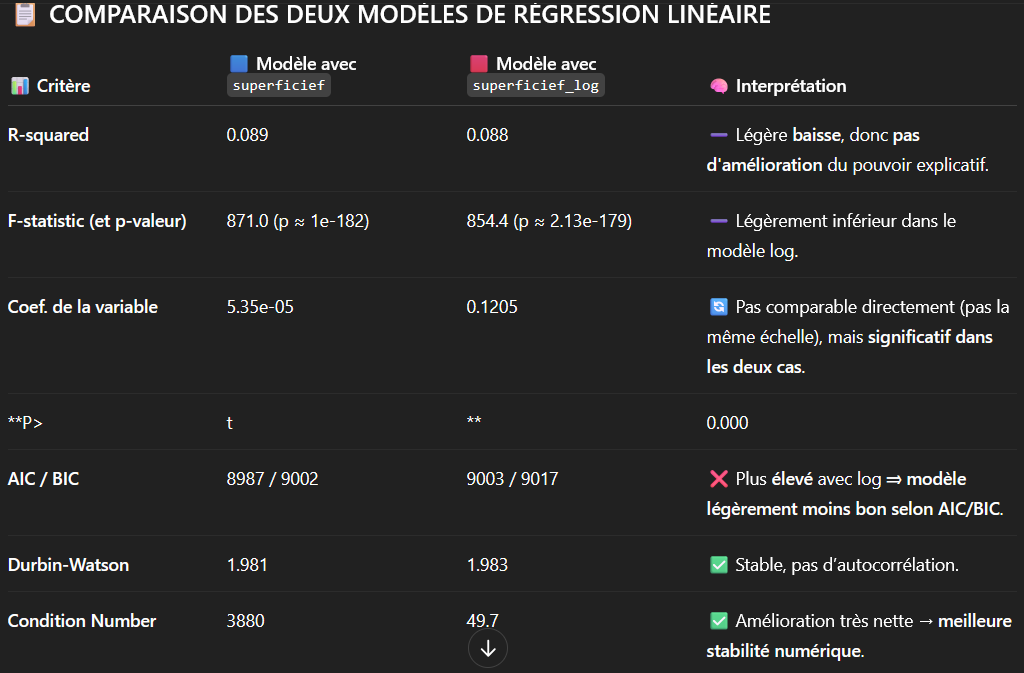

Nous pouvons faire une transformation logarithmique sur notre dataset, car la variable superficief est très déséquilibrée (forte asymétrie, valeurs très concentrées vers le bas et quelques très grandes valeurs).

✅ Avantage du modèle log :

    Moins de problèmes numériques (Cond. No. passe de 3880 à 49.7).

    Variable toujours significative.

    Plus interprétable visuellement, surtout si les valeurs de superficief étaient très dispersées (effet écrasement).

❌ Inconvénients / constat :

    R² légèrement plus bas → la transformation n’améliore pas l’ajustement global.

    AIC/BIC légèrement moins bons, donc le modèle brut est légèrement préféré par ces critères.

**Donc : ce n’est pas une amélioration en performance brute, mais c’est un meilleur modèle en stabilité et compréhension.**

## 4.3. Régression linéaire multivariée
On a besoin d'autres variables pour faire une Régression linéaire multivariée : Ce serait bien d'ajouter la variable 'EXPO' + trouver des données externes

---



In [507]:
most_corr_feats = \
    feature_engineering.get_most_correlated(
            df_train_cleaned)
most_corr_feats

superficief  superficief_log    0.806
             target             0.299
target       superficief_log    0.296
ft_4_categ   ft_21_categ        0.288
ft_22_categ  superficief_log    0.258
Identifiant  ft_4_categ         0.232
ft_19_categ  ft_22_categ        0.212
superficief  ft_22_categ        0.198
ft_19_categ  superficief_log    0.181
ft_21_categ  ft_22_categ       -0.149
ft_19_categ  superficief        0.130
Identifiant  superficief_log    0.115
             superficief        0.111
ft_21_categ  target             0.110
Identifiant  ft_21_categ        0.101
EXPO         target             0.100
Identifiant  ft_19_categ       -0.082
ft_19_categ  target             0.076
Identifiant  EXPO              -0.074
ft_4_categ   superficief_log    0.057
EXPO         ft_4_categ        -0.056
ft_4_categ   target             0.056
             superficief        0.051
Identifiant  ft_2_categ         0.048
             target             0.045
ft_4_categ   ft_22_categ       -0.038
superficief 

In [508]:
cols = ['superficief_log', 'EXPO']

# We do not need to reshape(-1,1) this time, as we
# have a matrix with two columns now.
X_train = df_train[cols ].values
model = AndreaLinearRegression()
model.fit(X_train, y_train, column_names=cols)
model.summary()

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.103
Model:                            OLS   Adj. R-squared:                  0.102
Method:                 Least Squares   F-statistic:                     354.9
Date:                Sat, 30 May 2026   Prob (F-statistic):          1.18e-146
Time:                        16:00:37   Log-Likelihood:                -3126.6
No. Observations:                6214   AIC:                             6259.
Df Residuals:                    6211   BIC:                             6279.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
intercept          -0.8128      0.041    -

In [509]:
X_test = df_test[cols ].values
y_pred = model.predict(X_test)

In [510]:
MSE = mean_squared_error(y_test, y_pred)
RMSE_some_features = math.sqrt(MSE)
print('RMSE now: ', RMSE_some_features, '; RMSE with one feature: ',
      RMSE_1_feature)

RMSE now:  0.39893625657706827 ; RMSE with one feature:  0.4008583724031047


## 4.4. Régression polynomiale univariée
On regarde quelles sont les variables les plus corrélées à target. La corrélation mesure dans quelle mesure deux variables varient ensemble.

---

In [511]:
feats = feature_engineering.get_features_correlated_to_target(
        df_train_cleaned,
        target_feature='target')
feats

target             1.00
superficief        0.30
superficief_log    0.30
ft_21_categ        0.11
EXPO               0.10
ft_19_categ        0.08
ft_4_categ         0.06
Identifiant        0.05
ft_22_categ        0.02
ft_2_categ        -0.01
Name: target, dtype: float64

[Text(0.5, 0, 'superficief'), Text(0, 0.5, 'target')]

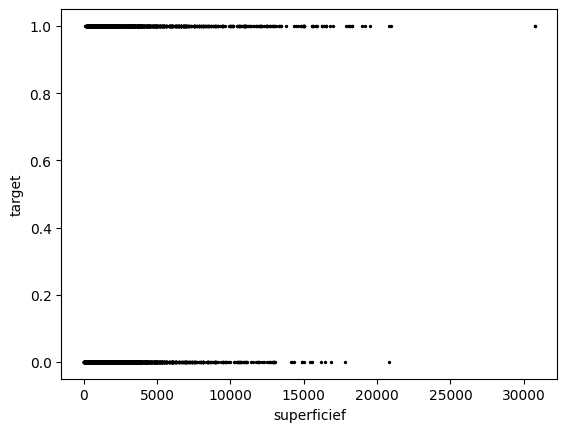

In [512]:
feature = 'superficief'
fig, ax = plt.subplots() # This creates just a canvas
ax.scatter(df_train_cleaned[feature],df_train_cleaned['target'],color='black',
           s=2, label='all samples') # ax is the actual figure
ax.set (xlabel=feature, ylabel='target')

In [513]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_train_poly

array([[ 7.17088848,  1.        , 51.42164157,  7.17088848,  1.        ],
       [ 8.36683531,  0.38356164, 70.0039331 ,  3.20919711,  0.14711953],
       [ 7.17088848,  1.        , 51.42164157,  7.17088848,  1.        ],
       ...,
       [ 7.71912984,  1.        , 59.5849655 ,  7.71912984,  1.        ],
       [ 6.41509696,  1.        , 41.153469  ,  6.41509696,  1.        ],
       [ 7.45240245,  1.        , 55.5383023 ,  7.45240245,  1.        ]])

In [514]:
# Entraînement du modèle polynomial

model_poly = AndreaLinearRegression()
model_poly.fit(X_train_poly, y_train)
model_poly.summary()

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.116
Model:                            OLS   Adj. R-squared:                  0.116
Method:                 Least Squares   F-statistic:                     163.6
Date:                Sat, 30 May 2026   Prob (F-statistic):          7.95e-164
Time:                        16:00:37   Log-Likelihood:                -3078.3
No. Observations:                6214   AIC:                             6169.
Df Residuals:                    6208   BIC:                             6209.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8339      0.183      4.569      0.0

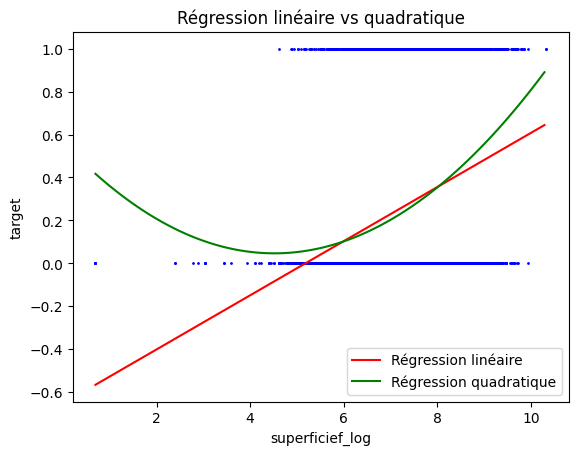

In [515]:
X_train = df_train[['superficief_log'] ].values
X_train = X_train.reshape(-1,1)
y_train = df_train['target'].values
X_test = df_test[[ 'superficief_log'] ].values.reshape(-1,1)
y_test = df_test['target'].values

# 1. Créer de nouvelles valeurs (intervalle) pour tracer la courbe prédite
interval = np.arange(X_train.min(), X_train.max(), 0.1).reshape(-1, 1)

# 2. Régression linéaire
model_lin = AndreaLinearRegression()
model_lin.fit(X_train, y_train, column_names=['superficief_log'])
h_values_lin = model_lin.predict(interval)

# 3. Régression quadratique
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
model_poly = AndreaLinearRegression()
model_poly.fit(X_train_poly, y_train, column_names=['superficief_log', 'superficief_log^2'])
interval_poly = poly.transform(interval)
h_values_poly = model_poly.predict(interval_poly)

# 4. Visualisation des deux
fig, ax = plt.subplots()
ax.scatter(df_train['superficief_log'], y_train, color='blue', s=1)
ax.plot(interval, h_values_lin, label="Régression linéaire", color='red')
ax.plot(interval, h_values_poly, label="Régression quadratique", color='green')
ax.set(ylabel="target", xlabel="superficief_log")
ax.legend()
plt.title("Régression linéaire vs quadratique")
plt.show()

**Interprétation — régression linéaire vs quadratique sur log(superficie)**

- **Axe X :** `superficief_log` = log(superficie + 1) pour réduire l'effet des très grands bâtiments.
- **Points bleus :** vrais `target` (0 ou 1) ; **rouge** = droite ; **vert** = courbe (degré 2).
- Si la courbe verte n'améliore pas beaucoup la RMSE → relation déjà **presque linéaire** après le log.
- Même limite qu'en 4.1 : prédire du 0/1 avec une régression continue.


In [516]:
from math import sqrt

X_test_poly = PolynomialFeatures(degree=2, include_bias=False).fit_transform(X_test)

y_train_pred = model_poly.predict(X_train_poly)
RMSE_train_quadr = sqrt(mean_squared_error(y_train_pred, y_train))

X_test_poly = poly.transform(X_test)

# Prédiction sur X_test
y_pred = model_poly.predict(X_test_poly)
RMSE_quadr = sqrt(mean_squared_error(y_pred, y_test))
print('The test error is ',RMSE_quadr,' seconds; with linear regression it was', RMSE_1_feature)

The test error is  0.39898214872909654  seconds; with linear regression it was 0.4008583724031047


train RMSE:  0.3993487617884122  seconds; With quadratic regression it was  0.3996482951944863
test RMSE:  0.39834876603826946  seconds; With quadratic regression it was  0.39898214872909654


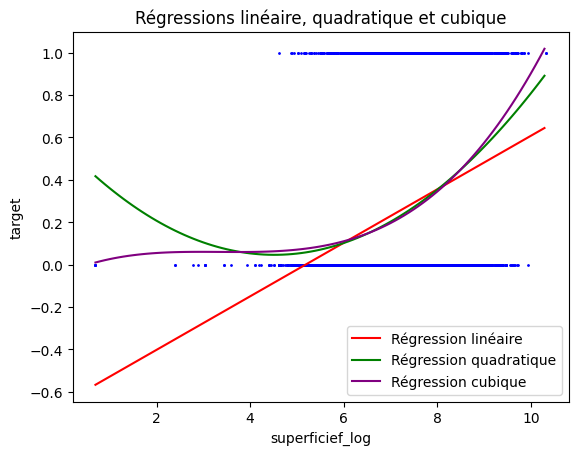

In [517]:
# Régression cubique

poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly3 = poly3.fit_transform(X_train)
X_test_poly3 = PolynomialFeatures(degree=3, include_bias=False).fit_transform(X_test)
model_cubic = AndreaLinearRegression()
model_cubic.fit(X_train_poly3, y_train, column_names=['superficief_log', 'superficief_log^2', 'superficief_log^3'])
interval_poly3 = poly3.transform(interval)
h_values_cubic = model_cubic.predict(interval_poly3)

# Calcul RMSE

y_train_pred = model_cubic.predict(X_train_poly3)
RMSE_train_cub = sqrt(mean_squared_error(y_train_pred, y_train))

y_pred = model_cubic.predict(X_test_poly3)
RMSE_cub = sqrt(mean_squared_error(y_pred, y_test))
print("train RMSE: ", RMSE_train_cub, " seconds; With quadratic regression it was ", RMSE_train_quadr)
print("test RMSE: ", RMSE_cub, " seconds; With quadratic regression it was ", RMSE_quadr)

# Visualisation

fig, ax = plt.subplots()
ax.scatter(df_train['superficief_log'], y_train, color='blue', s=1)
ax.plot(interval, h_values_lin, label="Régression linéaire", color='red')
ax.plot(interval, h_values_poly, label="Régression quadratique", color='green')
ax.plot(interval, h_values_cubic, label="Régression cubique", color='purple')
ax.set(ylabel="target", xlabel="superficief_log")
ax.legend()
plt.title("Régressions linéaire, quadratique et cubique")
plt.show()

**Interprétation — régressions linéaire, quadratique et cubique**

- Sur **log(superficie)** : comparaison de complexités (droite, courbe, courbe plus flexible).
- Si la **RMSE** test ne baisse presque pas du linéaire au cubique → pas besoin de modèle très complexe sur cette seule variable.
- Risque du polynôme élevé : **sur-apprentissage** (mieux sur le train, pas sur le test) — d'où la section 4.5 (Ridge).


## 4.5. Régression polynomiale avec régularisation

In [518]:
features = ['superficief']

X = df_train_cleaned[features].values
y = df_train_cleaned['target'].values

X_train, X_test, y_train, y_test =train_test_split(X,y, test_size=0.3, shuffle=True, random_state=7)

,alphas,cross-validation errors
0,1e-09,0.399981
1,0.5,0.399981
2,1,0.399981
3,10,0.399981
4,100,0.399981
5,1000,0.399981
6,10000,0.399981
7,100000.0,0.399981
8,1000000.0,0.399981


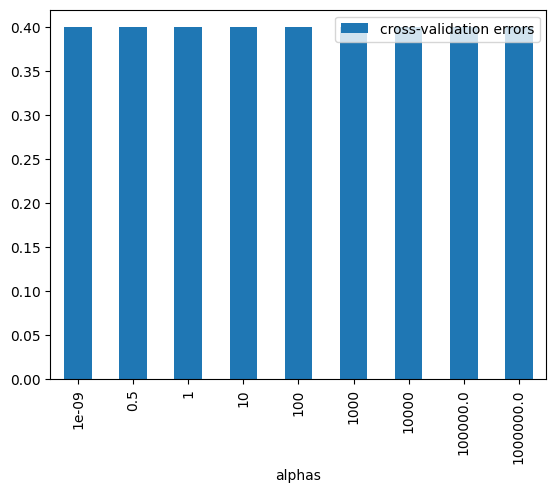

In [519]:
from sklearn.linear_model import Ridge

k_fold = KFold(n_splits=5, shuffle=True, random_state=10)

alphas = [1e-9, 0.5, 1, 10, 100, 1000, 10000, 1e5, 1e6]
errors = []
for a in alphas:
    scores = cross_val_score(Ridge(alpha=a),
                X_train, y_train, cv=k_fold,
                scoring = 'neg_mean_squared_error')
    errors.append(sqrt(mean(-scores) ) )

# We convert x-values to string because otherwise they would
# be to far from each other
df_errors = pd.DataFrame({'alphas':[str(a) for a in alphas],
                        'cross-validation errors':errors})
ax = df_errors.plot.bar(x='alphas')
df_errors

In [520]:
from sklearn.pipeline import make_pipeline

def MyPolynomialRegression(degree=2, include_bias_=False,
                           alpha=1e-9):
    return make_pipeline(PolynomialFeatures(degree,
                                            include_bias=include_bias_),
                Ridge(alpha=alpha) )

,alphas,errors
0,0.5,0.398571
1,1,0.398571
2,10,0.398571
3,100,0.398571
4,1000,0.398571
5,100000.0,0.398571
6,1000000.0,0.398571
7,10000000.0,0.398567
8,1000000000.0,0.398481
9,1000000000000.0,0.410040


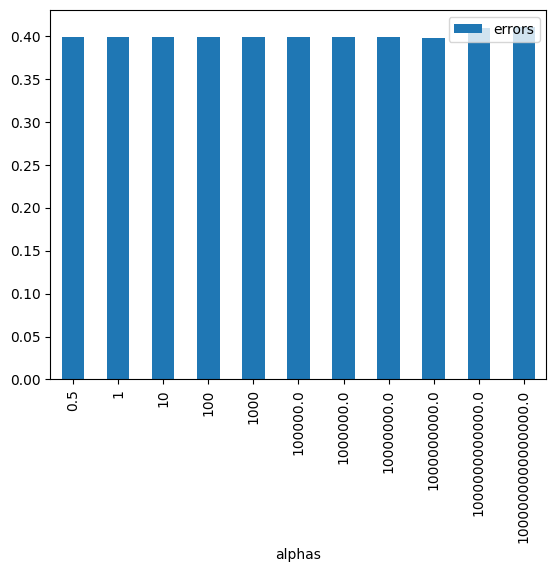

In [521]:
alphas = [0.5, 1, 10, 100, 1000, 1e5, 1e6, 1e7, 1e9, 1e12, 1e15]
errors = []
for a in alphas:
    scores = cross_val_score(MyPolynomialRegression(degree=2,
                    include_bias_=False, alpha=a),
                X_train, y_train, cv=k_fold,
                scoring = 'neg_mean_squared_error')
    errors.append(sqrt(mean(-scores) ) )

df_errors = pd.DataFrame({'alphas':[str(a) for a in alphas],
                        'errors':errors})
ax = df_errors.plot.bar(x='alphas')
df_errors

In [522]:
# Let's compute the test error for the best alpha

model = MyPolynomialRegression(degree=2, alpha=1e9)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
RMSE_poly_and_ridge = sqrt(mean_squared_error(y_pred, y_test) )
print("RMSE_poly_and_ridge: ", RMSE_poly_and_ridge,
      "\nRMSE poly without ridge: ", RMSE_quadr,
      "\nRMSE linear: ", RMSE_1_feature)

RMSE_poly_and_ridge:  0.4029950677942624 
RMSE poly without ridge:  0.39898214872909654 
RMSE linear:  0.4008583724031047


Normalisation (Feature scaling)

In [523]:
# Let's construct a pipeline with scaling and Ridge regression.

def MyScalingAndPolyRidge(degree=2, alpha=2):
    return make_pipeline(
       PolynomialFeatures(degree=degree, include_bias=False),
        StandardScaler(),
        Ridge(alpha=alpha)
    )

,alphas,errors
0,1e-09,0.398571
1,1e-07,0.398571
2,0.0001,0.398571
3,0.001,0.398571
4,0.1,0.398571
5,0.2,0.398571
6,0.5,0.398570
7,1,0.398568
8,10,0.398538
9,100,0.398438


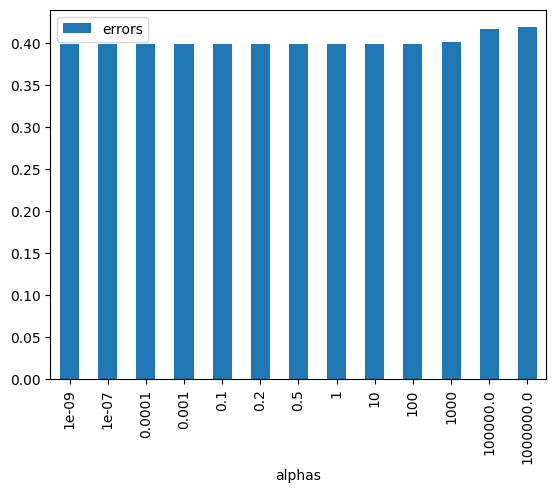

In [524]:
from sklearn.preprocessing import StandardScaler

alphas = [1e-9, 1e-7, 1e-4, 1e-3, 0.1, 0.2, 0.5, 1, 10, 100, 1000, 1e5, 1e6]
errors = []
for a in alphas:
    scores = cross_val_score(MyScalingAndPolyRidge(degree=2,
                    alpha=a),
                X_train, y_train, cv=k_fold,
                scoring = 'neg_mean_squared_error')
    errors.append(sqrt(mean(-scores) ) )

df_errors = pd.DataFrame({'alphas':[str(a) for a in alphas],
                        'errors':errors})
ax = df_errors.plot.bar(x='alphas')
df_errors

In [525]:
model = MyScalingAndPolyRidge(degree=2,
                    alpha=100)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
RMSE_scaling_and_poly_and_ridge = \
    sqrt(mean_squared_error(y_pred, y_test) )

print("RMSE_scaling_and_poly_and_ridge: ", RMSE_scaling_and_poly_and_ridge,"\nRMSE_poly_and_ridge:", RMSE_poly_and_ridge)

RMSE_scaling_and_poly_and_ridge:  0.4029162590563724 
RMSE_poly_and_ridge: 0.4029950677942624


## 4.6. Régression logistique

In [526]:
df_train,df_test = train_test_split(df_train_cleaned, test_size=0.2, random_state=1)

columns = ['superficief', 'EXPO']

X_train = df_train[columns]
X_test = df_test[columns]
y_train = df_train['target']
y_test = df_test['target']

Par défaut, la régression logistique ajoute une régularisation avec un poids C. On essaie sans régularisation dans un premier temps

In [527]:
# We cannot directly write `C=0`, as the library wants `C`>0, so we just provide a very small `C`

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(C=1e-9)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1e-09
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`m

In [528]:
y_pred_proba = model.predict_proba(X_test)
y_pred_proba

array([[0.83201527, 0.16798473],
       [0.84542079, 0.15457921],
       [0.79997753, 0.20002247],
       ...,
       [0.76934725, 0.23065275],
       [0.81325229, 0.18674771],
       [0.83713092, 0.16286908]])

In [529]:
# The actual prediction is :

y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [530]:
# Let's have a look at the predictions vs. the true value

pd.DataFrame({'true':y_test, 'pred':y_pred })

,true,pred
1356,0,0
3685,0,0
9518,0,0
2227,0,0
1757,0,0
...,...,...
4665,1,0
400,0,0
1404,1,0
6820,0,0


In [531]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.7730855855855856

In [532]:
RMSE_reg_logistique = sqrt(mean_squared_error(y_pred, y_test) )
print("RMSE régression logistique: ", RMSE_reg_logistique,
      "\nRMSE polynomiale avec régularisation: ", RMSE_poly_and_ridge,
      "\nRMSE polynomiale sans régularisation: ", RMSE_quadr,
      "\nRMSE régression linéaire: ", RMSE_1_feature)

RMSE régression logistique:  0.4763553446896701 
RMSE polynomiale avec régularisation:  0.4029950677942624 
RMSE polynomiale sans régularisation:  0.39898214872909654 
RMSE régression linéaire:  0.4008583724031047


________________________________________________________________________________

Normalization

________________________________________________________________________________

In [533]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)

model = LogisticRegression(C=1)
model.fit(X_train_scaled, y_train)
X_test_scaled = scaler.transform(X_test)
y_pred = model.predict(X_test_scaled)

In [534]:
accuracy_score(y_pred, y_test)

0.7736486486486487

Normalized confusion matrix
[[0.97434018 0.02565982]
 [0.8907767  0.1092233 ]]


<Axes: title={'center': 'Normalized confusion matrix'}, xlabel='Predicted label', ylabel='True label'>

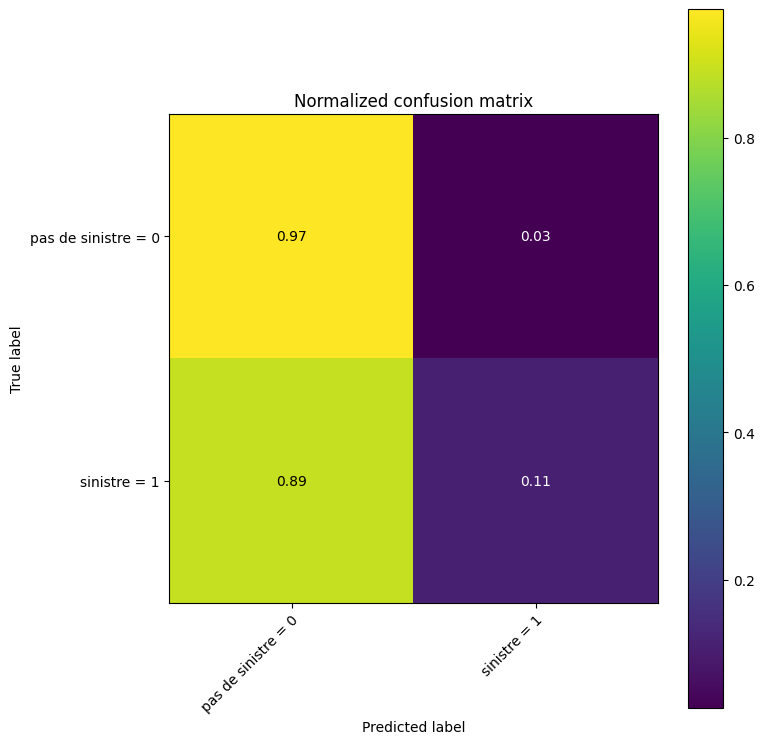

In [535]:
class_names = np.array(['pas de sinistre = 0', 'sinistre = 1'])
plot_conf_mat(y_test, y_pred, class_names)

**Interprétation — matrice de confusion normalisée** (régression logistique, **sans SMOTE**)

Chaque **ligne** = ce qui s'est **réellement** passé ; chaque **colonne** = ce que le modèle a **prédit**. Les chiffres sont des **% par ligne** (chaque ligne = 100 %).

|  | Prédit : pas de sinistre (0) | Prédit : sinistre (1) |
|--|------------------------------|------------------------|
| **Vrai : pas de sinistre (0)** | **~97 %** — bien classés | **~3 %** — fausses alertes |
| **Vrai : sinistre (1)** | **~89 %** — sinistres **ratés** | **~11 %** — sinistres **détectés** |

**Ce qu'il faut retenir :**

- Le modèle est **très bon** quand il n'y a **pas** eu de sinistre (97 % sur la ligne du haut).
- Il est **très mauvais** pour repérer les **vrais** sinistres : il ne les trouve qu'environ **11 %** des cas (il prédit « pas de sinistre » dans **89 %** des vrais sinistres).
- Comportement typique avec **déséquilibre** (~77 % sans sinistre) : le modèle favorise la classe **majoritaire** → une **accuracy** élevée (~77 %) peut **tromper**.
- **Pour Generali / le Gini**, ce qui compte est de **classer** les bâtiments à risque en haut de liste, pas seulement d'avoir beaucoup de « 0 » corrects.

**Suite du notebook :** la cellule **SMOTE** rééquilibre l'entraînement pour essayer d'**augmenter** la détection des sinistres — comparer avec la matrice **après SMOTE** juste en dessous.



________________________________________________________________________________

SMOTE pour la classification déséquilibrée

________________________________________________________________________________

In [536]:
df_train_cleaned['target'].value_counts()

target
0    6840
1    2038
Name: count, dtype: int64

La classification déséquilibrée implique le développement de modèles prédictifs sur des ensembles de données de classification présentant un déséquilibre de classe important.

La difficulté de travailler avec des ensembles de données déséquilibrés réside dans le fait que la plupart des techniques d'apprentissage automatique ignorent la classe minoritaire et, par conséquent, produisent de mauvaises performances sur celle-ci, alors que c'est généralement cette performance qui est la plus importante.

Une approche pour traiter les ensembles de données déséquilibrés consiste à suréchantillonner la classe minoritaire. La méthode la plus simple consiste à dupliquer des exemples dans la classe minoritaire, bien que ces exemples n'apportent aucune information nouvelle au modèle. De nouveaux exemples peuvent être synthétisés à partir des exemples existants. Il s'agit d'un type d'augmentation des données pour la classe minoritaire, appelé technique de suréchantillonnage synthétique des minorités, ou SMOTE.

In [ ]:
try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn", "-q"])
    from imblearn.over_sampling import SMOTE

smote = SMOTE()

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
pd.value_counts(y_train_balanced)

C:\Users\nassi\AppData\Local\Temp\ipykernel_31284\2761395082.py:11: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(y_train_balanced)


target
0    5476
1    5476
Name: count, dtype: int64

Normalized confusion matrix
[[0.77199413 0.22800587]
 [0.52427184 0.47572816]]


<Axes: title={'center': 'Normalized confusion matrix'}, xlabel='Predicted label', ylabel='True label'>

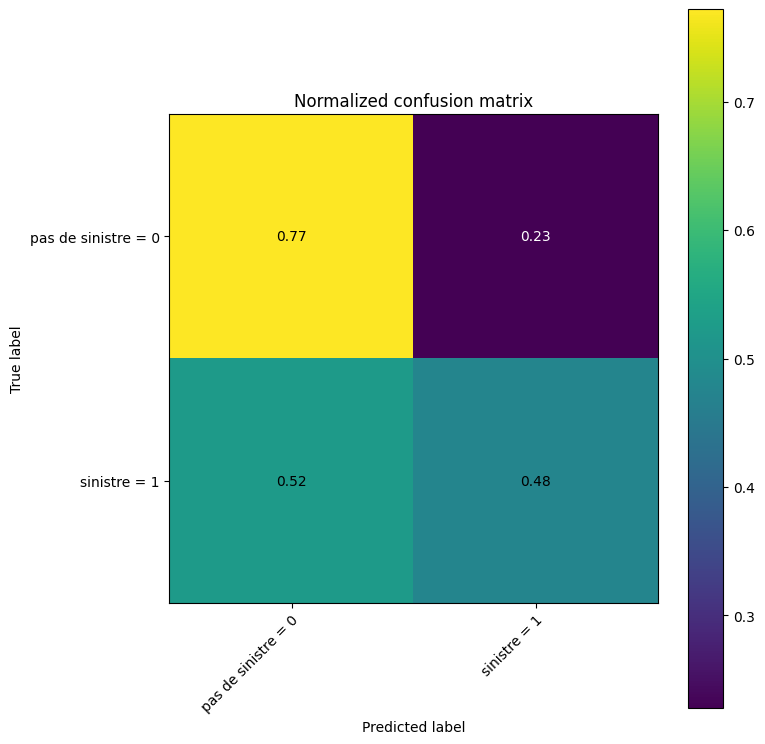

In [ ]:
model.fit(X_train_balanced, y_train_balanced)
y_pred = model.predict(X_test)
plot_conf_mat(y_test, y_pred, class_names)

**Interprétation — matrice de confusion** (régression logistique, **avec SMOTE** sur le train)

Comparer avec la matrice **sans SMOTE** (cellule au-dessus) :

| Question | À observer |
|----------|------------|
| Case bas-droite (vrais sinistres bien prédits) | A-t-elle **augmenté** par rapport à ~11 % ? |
| Case bas-gauche (sinistres ratés) | A-t-elle **baissé** par rapport à ~89 % ? |
| Case haut-droite (fausses alertes) | Souvent **un peu plus haute** — compromis normal |

SMOTE force le modèle à ne pas ignorer la classe **sinistre** à l'entraînement ; le Gini sur le challenge reste à valider sur le jeu de test officiel.



In [ ]:
accuracy_score(y_pred, y_test)

0.7032657657657657

## 4.7. Forêt aléatoire

In [ ]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss
from collections import Counter
from imblearn.over_sampling import SMOTE
from collections import Counter

# Import the visualization library I prepared for you
# visualization déjà importé (section 1)
from visualization import plot_conf_mat, plot_feature_importances

# Colab : %load_ext autotime
pass

In [ ]:
model = RandomForestClassifier(n_estimators=100,
                      criterion='gini',
                      max_leaf_nodes=16, # Each tree cannot have more than that
                      random_state=5, # For reproducibility
                      n_jobs=-1, # Use all the CPUs
                      )

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",16
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

Normalized confusion matrix
[[0.97507331 0.02492669]
 [0.89320388 0.10679612]]


<Axes: title={'center': 'Normalized confusion matrix'}, xlabel='Predicted label', ylabel='True label'>

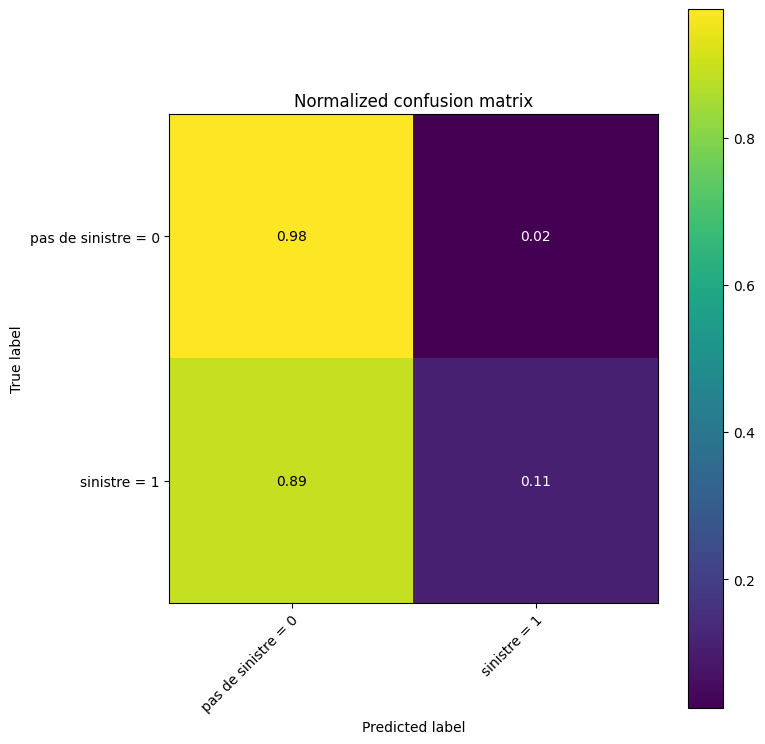

In [ ]:
y_pred = model.predict(X_test)

class_names = np.array(['pas de sinistre = 0', 'sinistre = 1'])
plot_conf_mat(y_test, y_pred, class_names)

**Interprétation — matrice de confusion** (forêt aléatoire, ce bloc)

Lecture **normalisée par ligne** (identique à la logistique) :
- **Haut-gauche** : part des « pas de sinistre » bien reconnus.
- **Bas-droite** : part des **vrais sinistres détectés** (à comparer à ~11 % de la logistique sans SMOTE).
- La forêt modélise des **relations non linéaires** entre superficief, EXPO et la cible.



In [ ]:
print( "Samples per class before SMOTE: ", Counter(y_train) )

smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

print( "Samples per class after SMOTE: ", Counter(y_train) )

Samples per class before SMOTE:  Counter({0: 5476, 1: 1626})
Samples per class after SMOTE:  Counter({0: 5476, 1: 5476})


Normalized confusion matrix
[[0.97507331 0.02492669]
 [0.89320388 0.10679612]]


<Axes: title={'center': 'Normalized confusion matrix'}, xlabel='Predicted label', ylabel='True label'>

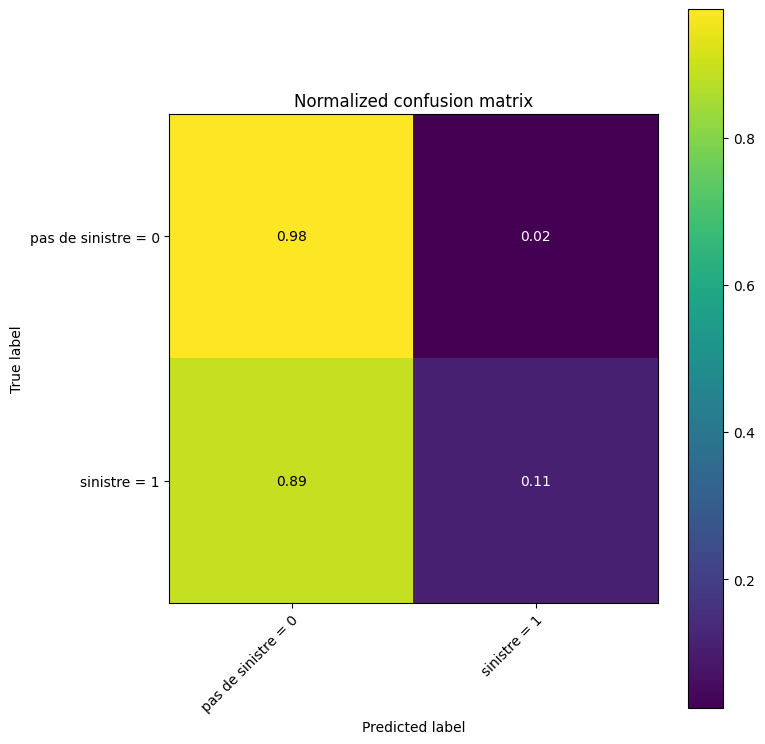

In [ ]:
y_pred = model.predict(X_test)

class_names = np.array(['pas de sinistre = 0', 'sinistre = 1'])
plot_conf_mat(y_test, y_pred, class_names)

**Interprétation — matrice de confusion** (forêt aléatoire, **après SMOTE** sur le train)

Comparer à la matrice **juste au-dessus** :
- La case **bas-droite** (sinistres bien détectés) devrait en général **augmenter**.
- La case **haut-droite** (fausses alertes) peut **augmenter** légèrement — compromis classique.



Importances des variables (Feature importances)

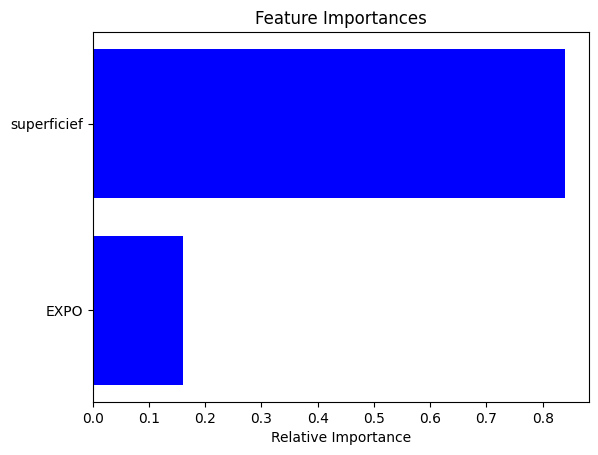

Index(['superficief', 'EXPO'], dtype='object')

In [ ]:
feature_names = X_test.columns
plot_feature_importances(model.feature_importances_, feature_names)
feature_names

**Interprétation — importances des variables (forêt aléatoire)**

- Plus la barre est **longue**, plus la variable a contribué aux décisions des arbres.
- Confirme souvent **superficief** et **EXPO** comme variables importantes (aligné avec l'EDA et le PDF du challenge).
- Les colonnes **t_*** affichées sont des codes **anonymisés** ; interpréter avec prudence (voir légende §3.2).



________________________________________________________________________________

Hyperparameter tuning

________________________________________________________________________________

In [ ]:
param_grid = {
    'criterion':['gini', 'entropy'],
    'max_features':[1,2,3,4,5],

    # Number of allowed leafs
    'max_leaf_nodes':[16, 32, 64, 128, 256, 512, 1024, 2048],

    # A node will be split if this split induces a decrease of the
    # impurity greater than or equal to this value.
    'min_impurity_decrease' : [0, 0.001, 0.01, 0.1, 0.2],

    'max_depth':[1,10,100,1000,10000,100000],

    # A node can be a leaf only if it contains at least the following fraction
    # of samples
    'min_weight_fraction_leaf' : [0.1, 0.01, 0.001, 0]
}

forest = RandomForestClassifier(n_estimators=100, random_state = 4, n_jobs=1,)

search = RandomizedSearchCV(
                            scoring = 'accuracy',
                            estimator = forest,
                            param_distributions = param_grid,
                            n_iter = 50, # We just test 50 configurations
                            verbose = 2,random_state=42,
                            n_jobs = -1,
                            cv = 5 # 5-fold validation
                          )
# Note that we are training different random forests in parallel (n_jobs=-1),
# each with a certain combination of hyper-parameters.

search.fit(X_train, y_train)


Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...andom_state=4)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['gini', 'entropy'], 'max_depth': [1, 10, ...], 'max_features': [1, 2, ...], 'max_leaf_nodes': [16, 32, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here...

In [ ]:
print(search.best_params_)

model = search.best_estimator_

{'min_weight_fraction_leaf': 0.001, 'min_impurity_decrease': 0.001, 'max_leaf_nodes': 32, 'max_features': 5, 'max_depth': 10000, 'criterion': 'entropy'}


Normalized confusion matrix
[[0.66055718 0.33944282]
 [0.39320388 0.60679612]]


<Axes: title={'center': 'Normalized confusion matrix'}, xlabel='Predicted label', ylabel='True label'>

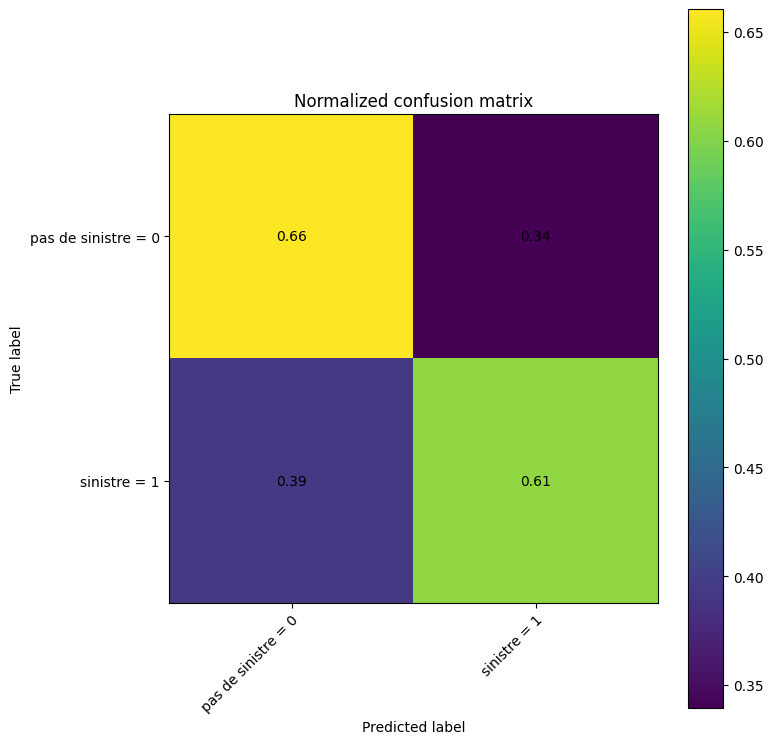

In [ ]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

plot_conf_mat(y_test, y_pred, class_names)

**Interprétation — matrice de confusion** (forêt aléatoire + **RandomizedSearchCV**)

Matrice du **meilleur** modèle après recherche d hyperparamètres. À confronter aux forêts simples : gain sur la ligne « vrai sinistre » ?



# 5. Réseau de neurones

### Prérequis — section 5 (MLP)

Utilise le **même jeu** que la régression logistique (section 4.6) : `superficief`, `EXPO`, données **normalisées**, **SMOTE** sur l’entraînement. Exécutez la cellule suivante si `X_train` / `y_train` ne sont plus en mémoire.

In [ ]:
cols_mlp = ["superficief", "EXPO"]
df_tr_mlp, df_te_mlp = train_test_split(df_train_cleaned, test_size=0.2, random_state=1)
X_train = df_tr_mlp[cols_mlp]
X_test = df_te_mlp[cols_mlp]
y_train = df_tr_mlp["target"]
y_test = df_te_mlp["target"]

_scaler_mlp = StandardScaler()
X_train = _scaler_mlp.fit_transform(X_train)
X_test = _scaler_mlp.transform(X_test)

from imblearn.over_sampling import SMOTE

X_train, y_train = SMOTE(random_state=42).fit_resample(X_train, y_train)
class_names = np.array(["pas de sinistre = 0", "sinistre = 1"])
print("MLP — train shape:", X_train.shape, "| test:", X_test.shape)

MLP — train shape: (10952, 2) | test: (1776, 2)


Accuracy: 0.69
Normalized confusion matrix
[[0.7441349  0.2558651 ]
 [0.49271845 0.50728155]]


<Axes: title={'center': 'Normalized confusion matrix'}, xlabel='Predicted label', ylabel='True label'>

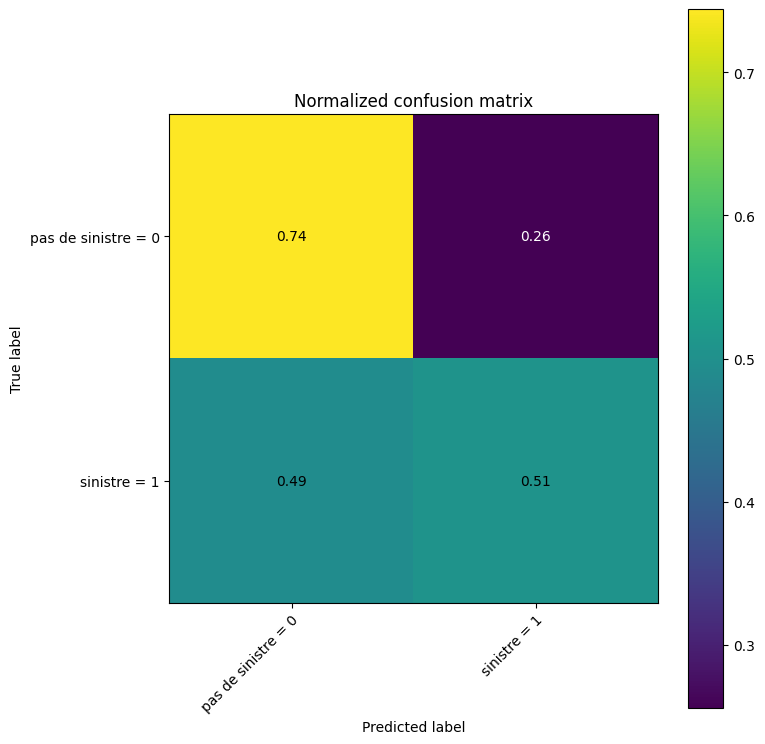

In [ ]:
from sklearn.neural_network import MLPClassifier
"""
model = MLPClassifier(
    activation="tanh",
    alpha=0.001,
    batch_size=128,
    early_stopping=True,
    hidden_layer_sizes=(40, 20, 20),
    learning_rate="adaptive",
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42,
    validation_fraction=0.1,
    n_iter_no_change=10
)
"""

model = MLPClassifier(
    activation="logistic",
    learning_rate_init=0.001,
    early_stopping=True,
    hidden_layer_sizes=(40, 40),
    max_iter=1000,
    random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')
plot_conf_mat(y_test, y_pred, class_names)


**Interprétation — matrice de confusion** (réseau de neurones **MLP**)

Même lecture par lignes (% normalisés). Comparer avec logistique et forêt sur superficief + EXPO.



In [ ]:
from scipy.stats import uniform, randint

# Define the model
model = MLPClassifier(random_state=42)

# Define the parameter grid
param_distributions = {
    'hidden_layer_sizes': [(10,), (20,), (30,), (40,), (50,), (40, 40), (50, 50, 30)],
    'activation': ['logistic', 'tanh', 'relu'],
    'alpha': uniform(0.0001, 0.1),  # Uniform distribution for alpha
    'learning_rate_init': uniform(0.0001, 0.01),  # Uniform distribution for learning rate
    'max_iter': randint(100, 1000),  # Random integer for max_iter
    'batch_size': [16, 32, 64, 128]
}

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    model,
    param_distributions,
    n_iter=10,  # Number of parameter combinations to try
    scoring='accuracy',
    cv=5,  # 5-fold cross-validation
    random_state=45,
    n_jobs=-1  # Use all available cores
)

# Fit the model
random_search.fit(X_train, y_train)

# Get the best parameters and score
best_params = random_search.best_params_
best_score = random_search.best_score_

# Evaluate the best model on the test set
best_model = random_search.best_estimator_
test_score = best_model.score(X_test, y_test)

print(f'Best Parameters: {best_params}')
print(f'Best Cross-Validation Score: {best_score:.2f}')
print(f'Test Set Score: {test_score:.2f}')

Best Parameters: {'activation': 'relu', 'alpha': 0.025103042784395912, 'batch_size': 16, 'hidden_layer_sizes': (10,), 'learning_rate_init': 0.005674327026820758, 'max_iter': 854}
Best Cross-Validation Score: 0.65
Test Set Score: 0.66


# 6.a K-means anomaly

### Prérequis — section 6 (K-means)

Exécutez d’abord les **sections 1 et 4** (ou au minimum la cellule qui crée `df_train_cleaned`). La cellule suivante construit `X`, `X_scaled`, `K=3` et un premier regroupement `clusters` **sans** `wget` (scripts déjà téléchargés en section 1).

In [ ]:
# Section 6 — K-means (local Windows : pas de wget)
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from andrea_models import subsample
from visualization import silhouette_diagram

_base = df_train_cleaned if "df_train_cleaned" in dir() else df.dropna().copy()
if _base["EXPO"].dtype == object:
    _base = _base.copy()
    _base["EXPO"] = _base["EXPO"].str.replace(",", ".", regex=False).astype(float)

feat_kmeans = ["superficief", "ft_2_categ", "ft_21_categ", "ft_22_categ", "EXPO"]
X = _base[feat_kmeans].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

K = 3
model = KMeans(n_clusters=K, random_state=42)
clusters = model.fit_predict(X_scaled)
print("K-means — forme X_scaled:", X_scaled.shape, "| effectifs par cluster:", np.bincount(clusters))

K-means — forme X_scaled: (8878, 5) | effectifs par cluster: [5518 2584  776]


In [ ]:
clusters[0:5]

array([1, 0, 0, 0, 0])

(array([5518.,    0.,    0.,    0.,    0., 2584.,    0.,    0.,    0.,
         776.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

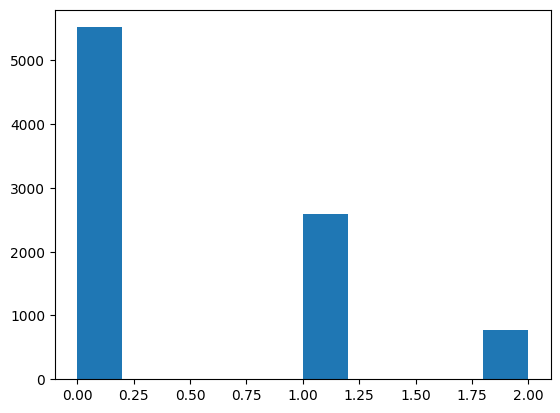

In [ ]:
plt.hist(clusters)

**Interprétation — répartition des clusters (K-means)**

- Chaque barre = nombre de bâtiments assignés à un **groupe** (cluster) après regroupement sur quelques variables numériques.
- Sert surtout à l'**exploration** (profils de parc), pas directement à la note Gini du challenge.
- Des clusters **très déséquilibrés** = un groupe dominant + petits groupes niche.


In [ ]:
model.inertia_

30237.979474562926

In [ ]:
n_samples = 8000
X_sub = subsample(X_scaled, n_samples)

In [ ]:
inertia_values = []

repeats = range(10, 200, 10)

for r in repeats:
  model = KMeans(K, n_init=r)
  model.fit_predict(X_sub)
  inertia_values.append(model.inertia_)
  print("Inertia with ", r, " initializations:", model.inertia_)

plt.plot(repeats, inertia_values)

Inertia with  10  initializations: 27189.28565901044
Inertia with  20  initializations: 27095.519484454293
Inertia with  30  initializations: 27095.500476406327
Inertia with  40  initializations: 27095.53989825258
Inertia with  50  initializations: 27095.547475953943
Inertia with  60  initializations: 27095.500476406327
Inertia with  70  initializations: 27095.547475953943
Inertia with  80  initializations: 27095.527938184583
Inertia with  90  initializations: 27095.519484454293
Inertia with  100  initializations: 27095.527938184583
Inertia with  110  initializations: 27095.500476406327
Inertia with  160  initializations: 27095.53989825258
Inertia with  170  initializations: 27095.53977683553


In [ ]:
n_init = 80

In [ ]:
print("Distances to be computed: ", "{:e}".format( X_scaled.shape[0]**2) )

Distances to be computed:  7.881888e+07


In [ ]:
model = KMeans(K, n_init=n_init)
clusters = model.fit_predict(X_sub)

In [ ]:
# The silhouette_score gives the average value for all the samples.
# This gives a perspective into the density and separation of the formed
# clusters
silhouette_avg = silhouette_score(X_sub, clusters)
silhouette_avg

0.2615550632659737

0.26222007148629306

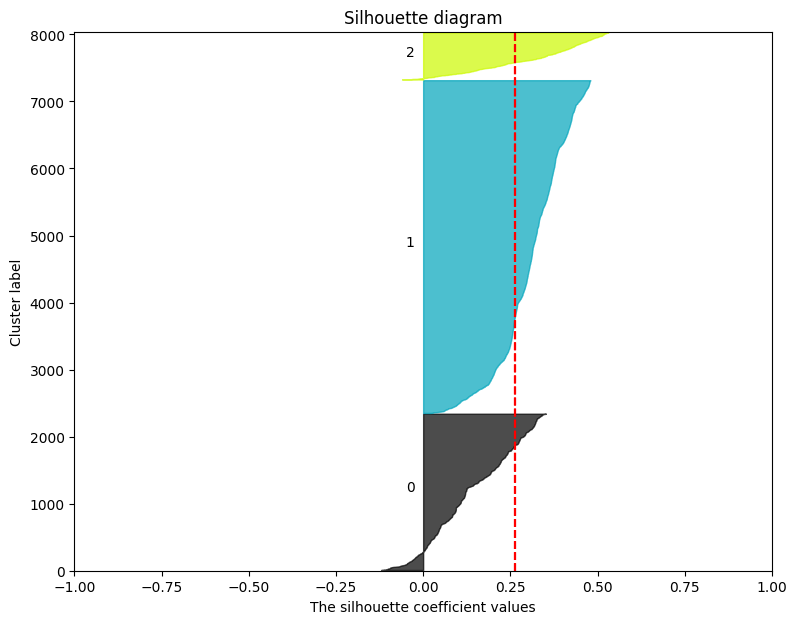

In [ ]:
sample_silhouette_values = silhouette_diagram(X_sub, clusters, K)